# Tunisair Flight Delay Prediction

Predicting flight delay duration for Tunisair using pre-departure attributes (schedule, route, aircraft), following the same leakage-safe workflow as `03_eda-and-modeling.ipynb`.

## Phase 1.1: Download flight delay dataset and load into data/

Download `train.csv` and `test.csv` from the [Zindi Flight Delay Prediction Challenge](https://zindi.africa/competitions/flight-delay-prediction-challenge/data) and place them in `data/` before running this cell.

**Before this step:** We don't have any data loaded into the notebook yet — just a plan.

**What this code does:** It brings in a toolbox called `pandas` (think of it like Excel, but controlled with code) and uses it to open the two data files (`train.csv` and `test.csv`) we downloaded from Zindi. Then it shows the first 5 rows so we can see what the data actually looks like.

**What we want to get out of it:** A first real look at the raw data — the columns we have, the format they're in, and confirmation the files loaded correctly before we do anything else.

In [1]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
train.head()

,ID,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12.55.00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16.55.00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06.45.00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17.00.00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15.50.00,ATA,TU 320IMU,22.0


## Phase 1.2: Add airportsdata dependency and enrich DEPSTN/ARRSTN

Join `DEPSTN`/`ARRSTN` to airport metadata via `airportsdata`.

**Before this step:** Our data only has 3-letter airport codes for where each flight departs from (`DEPSTN`) and arrives at (`ARRSTN`), like `"CMN"` or `"TUN"`. On their own, these codes don't mean anything to a model — it can't learn that `"CMN"` is in Morocco or that two airports are in different timezones just from the code itself.

**What this code does:** It uses a reference library called `airportsdata`, which is like a big lookup table of airport codes and their real-world details (country, latitude, longitude, timezone). For each airport code in our data, it looks up this information and adds it as brand new columns — `dep_country`, `dep_lat`, `dep_lon`, `dep_tz` for the departure airport, and the same with `arr_` for the arrival airport. One airport, `SXF` (Berlin-Schönefeld), isn't in that library anymore because it closed in 2020, so we added its details manually as a backup (see `ISSUES.md`).

**What we want to get out of it:** Turning meaningless 3-letter codes into useful, model-friendly information — like how far apart two airports are, or whether a flight crosses a timezone — which is more likely to help predict delays than the raw airport code alone.

In [2]:
import airportsdata

airports = airportsdata.load("IATA")

# Manual override: SXF (Berlin-Schoenefeld) was decommissioned in 2020 (merged into
# Berlin Brandenburg/BER) and is no longer in airportsdata's current tables, even
# though it's a valid code in this 2016-2018 dataset. See ISSUES.md.
AIRPORT_OVERRIDES = {
    "SXF": {"country": "DE", "lat": 52.3667, "lon": 13.5033, "tz": "Europe/Berlin"},
}


def enrich_airport_columns(df, code_col, prefix):
    def lookup(code):
        return airports.get(code) or AIRPORT_OVERRIDES.get(code)

    codes = df[code_col].map(lookup)
    df[f"{prefix}_country"] = codes.map(lambda a: a["country"] if isinstance(a, dict) else None)
    df[f"{prefix}_lat"] = codes.map(lambda a: a["lat"] if isinstance(a, dict) else None)
    df[f"{prefix}_lon"] = codes.map(lambda a: a["lon"] if isinstance(a, dict) else None)
    df[f"{prefix}_tz"] = codes.map(lambda a: a["tz"] if isinstance(a, dict) else None)
    return df


for _df in (train, test):
    enrich_airport_columns(_df, "DEPSTN", "dep")
    enrich_airport_columns(_df, "ARRSTN", "arr")

print("Unmatched DEPSTN codes:", train.loc[train["dep_country"].isna(), "DEPSTN"].unique())
print("Unmatched ARRSTN codes:", train.loc[train["arr_country"].isna(), "ARRSTN"].unique())

train[["DEPSTN", "dep_country", "dep_lat", "dep_lon", "dep_tz", "ARRSTN", "arr_country"]].head()

Unmatched DEPSTN codes: <StringArray>
[]
Length: 0, dtype: str
Unmatched ARRSTN codes: <StringArray>
[]
Length: 0, dtype: str


,DEPSTN,dep_country,dep_lat,dep_lon,dep_tz,ARRSTN,arr_country
0,CMN,MA,33.3675,-7.58997,Africa/Casablanca,TUN,TN
1,MXP,IT,45.6306,8.72811,Europe/Rome,TUN,TN
2,TUN,TN,36.8510,10.22720,Africa/Tunis,IST,TR
3,DJE,TN,33.8750,10.77550,Africa/Tunis,NTE,FR
4,TUN,TN,36.8510,10.22720,Africa/Tunis,ALG,DZ


## Phase 1.3: Explore raw schema (dtypes, shape, missingness, target distribution)

**Before this step:** We've seen the first few rows, but we don't yet know the full shape of the table or whether any values are missing.

**What this code does:** `.info()` asks pandas for a summary report card of the whole table: how many rows there are, what each column is called, how many values are filled in ("non-null"), and what type of data each column holds (text, numbers, etc.).

**What we want to get out of it:** A quick health check — are there any obviously missing values, and are the column types what we'd expect (e.g. is a date column being read as an actual date, or just as plain text)?

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 107833 entries, 0 to 107832
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           107833 non-null  str    
 1   DATOP        107833 non-null  str    
 2   FLTID        107833 non-null  str    
 3   DEPSTN       107833 non-null  str    
 4   ARRSTN       107833 non-null  str    
 5   STD          107833 non-null  str    
 6   STA          107833 non-null  str    
 7   STATUS       107833 non-null  str    
 8   AC           107833 non-null  str    
 9   target       107833 non-null  float64
 10  dep_country  107833 non-null  str    
 11  dep_lat      107833 non-null  float64
 12  dep_lon      107833 non-null  float64
 13  dep_tz       107833 non-null  str    
 14  arr_country  107833 non-null  str    
 15  arr_lat      107833 non-null  float64
 16  arr_lon      107833 non-null  float64
 17  arr_tz       107833 non-null  str    
dtypes: float64(5), str(13)
memory usage

**Before this step:** We know the overall shape of the data, but not which specific columns (if any) have gaps.

**What this code does:** For every column, it calculates the percentage of rows where that column is empty, then sorts the list so the columns with the most missing values appear first.

**What we want to get out of it:** Confirmation of exactly which columns would need extra care later (e.g. filling in missing values). In this dataset it turns out every column is 100% complete — no missing data to worry about.

In [4]:
# Missingness per column
train.isna().mean().sort_values(ascending=False)

ID             0.0
DATOP          0.0
FLTID          0.0
DEPSTN         0.0
ARRSTN         0.0
STD            0.0
STA            0.0
STATUS         0.0
AC             0.0
target         0.0
dep_country    0.0
dep_lat        0.0
dep_lon        0.0
dep_tz         0.0
arr_country    0.0
arr_lat        0.0
arr_lon        0.0
arr_tz         0.0
dtype: float64

**Before this step:** We know the data is complete, but we haven't looked closely at what we're actually trying to predict.

**What this code does:** `target` is the column holding the flight delay in minutes — the thing our model needs to learn to predict. `.describe()` gives standard statistics about it: the average, the smallest and largest values, and how spread out the numbers are.

**What we want to get out of it:** A feel for what "normal" looks like for a flight delay here — for example, whether most delays are small, whether there are a few extreme outliers, and a check that the numbers never go negative (which wouldn't make sense).

In [5]:
# Target distribution
train["target"].describe()

count    107833.000000
mean         48.733013
std         117.135562
min           0.000000
25%           0.000000
50%          14.000000
75%          43.000000
max        3451.000000
Name: target, dtype: float64

**Before this step:** The `.describe()` numbers above already hint at something important — the middle 50% of flights (25th to 75th percentile) are delayed somewhere between 0 and 43 minutes, but the single largest delay is 3451 minutes (almost 2.5 days!). Numbers alone can be hard to picture, so a chart will make this much clearer.

**What this code does:** Draws a histogram — a bar chart where each bar shows how many flights fall into a given delay-length range (e.g. how many flights were delayed 0-10 minutes, 10-20 minutes, and so on).

**What we want to get out of it:** A visual, at-a-glance sense of the shape of flight delays: are most flights on time with just a few big outliers dragging the average up, or is it more evenly spread out? This directly informs the next step (#4), where we decide what to do about any extreme values.

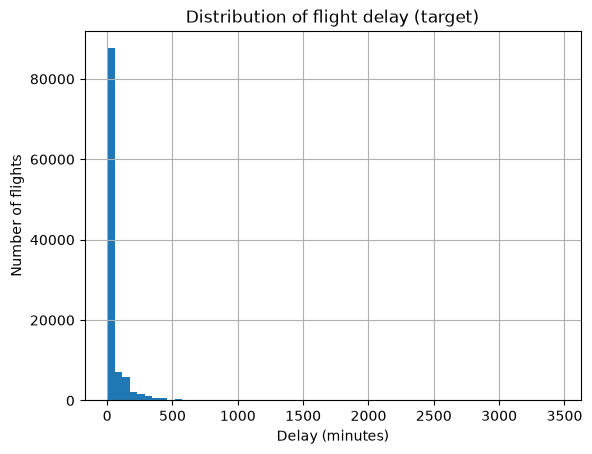

In [6]:
import matplotlib.pyplot as plt

train["target"].hist(bins=60)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of flight delay (target)")
plt.show()

**Before this step:** The full-range histogram above stretches all the way out to 3451 minutes, so almost all flights get squashed into a single tall bar near zero — it's hard to see any real shape in the bulk of the data.

**What this code does:** Draws the same kind of histogram, but only for flights delayed 1500 minutes or less, temporarily hiding the handful of most extreme outliers. This doesn't change or remove any data — `train` itself is untouched, we're just choosing what to display in this one chart.

**What we want to get out of it:** A clearer, more readable view of how delays are distributed for the typical flight, without a few extreme outliers stretching the chart out of proportion.

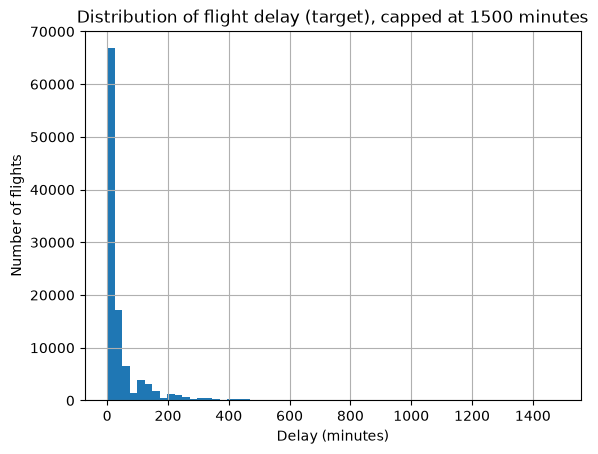

In [7]:
train.loc[train["target"] <= 1500, "target"].hist(bins=60)
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of flight delay (target), capped at 1500 minutes")
plt.show()

**Takeaway (Phase 1.3):** The distribution is heavily **right-skewed** — the vast majority of flights (around 65,000+) are delayed by roughly 0-20 minutes, with the bar count dropping off sharply after that. By around 400-500 minutes there are barely any flights left, and this chart doesn't even show the most extreme cases (delays stretch out to 3451 minutes in the uncapped view). This "long tail" shape is typical for delay data: being on time or slightly late is normal, while very long delays are rare but do happen. This confirms what the `.describe()` numbers suggested and sets up the next step, where we decide how to handle those rare extreme values.

**Before this step:** We've looked closely at the target's shape; one more basic data-quality check is worth doing while we're here.

**What this code does:** Counts how many rows in `train` are exact duplicates of another row.

**What we want to get out of it:** Peace of mind that we're not accidentally double-counting any flights before building anything on top of this data.

In [8]:
# Check for exact duplicate rows.
print("Duplicate rows in train:", train.duplicated().sum())

Duplicate rows in train: 0


## Phase 1.4: Analyze target distribution and flag outliers/impossible values

**Before this step:** We've seen visually that a small number of flights have very large delays, but we haven't quantified exactly how many, or double-checked that nothing in the data is outright impossible (like a negative delay).

**What this code does:** Confirms again there are zero negative delays (which would be an impossible value), then counts how many flights fall above a few different delay thresholds (500, 1000, 2000 minutes).

**What we want to get out of it:** A concrete count of how many "extreme" flights we're actually talking about, so we can make an informed decision about whether to drop, cap, or keep them — rather than guessing from the chart alone.

In [9]:
print("Negative delays (impossible):", (train["target"] < 0).sum())
for threshold in (500, 1000, 2000):
    count = (train["target"] > threshold).sum()
    pct = count / len(train) * 100
    print(f"Flights delayed more than {threshold} min: {count} ({pct:.2f}%)")

Negative delays (impossible): 0
Flights delayed more than 500 min: 1185 (1.10%)
Flights delayed more than 1000 min: 197 (0.18%)
Flights delayed more than 2000 min: 44 (0.04%)


**Decision (Phase 1.4):** No impossible values were found — zero negative delays. Extreme delays are rare (1,185 flights, 1.10%, over 500 min; 197, 0.18%, over 1000 min; 44, 0.04%, over 2000 min) but not data errors — they most likely reflect genuine severe disruptions (weather, mechanical issues, crew problems), not mistakes in the data.

**We are keeping all rows, with no drop or cap on `target`.** Since our evaluation metric is RMSE, which specifically rewards correctly capturing the full distribution (including the tail), removing or capping this small fraction would only discard real signal about the kind of large delays an airline operations team most needs to anticipate — without fixing anything that's actually wrong.

## Phase 1.5: Investigate temporal range and ordering of DATOP/STD/STA

**Before this step:** The `STD` column (scheduled departure time) is stored as plain text, like `"2016-01-03 10:30:00"`. To a computer, that's just a string of characters, not something it understands as an actual point in time — so it can't do date/time math with it (like sorting flights chronologically).

**What this code does:** It tells pandas to convert the `STD` column from plain text into a real date-and-time value it understands, for both the training and test data.

**What we want to get out of it:** A proper date/time column we can use later — for example, to sort flights by date or pull out things like the hour of departure.

In [10]:
# STD (scheduled time of departure) already uses colon-separated time
# (e.g. "10:30:00"), so it parses directly with pd.to_datetime.
for _df in (train, test):
    _df["STD"] = pd.to_datetime(_df["STD"])

train[["STD"]].head()

,STD
0,2016-01-03 10:30:00
1,2016-01-13 15:05:00
2,2016-01-16 04:10:00
3,2016-01-17 14:10:00
4,2016-01-17 14:30:00


**Before this step:** The `STA` column (scheduled arrival time) is also plain text, like `"2016-01-03 12.55.00"` — but notice it uses dots (`.`) between hours, minutes, and seconds instead of colons (`:`) like `STD` does. This is a data-entry inconsistency, and pandas can't understand `12.55.00` as a time on its own.

**What this code does:** First it fixes the formatting problem by swapping those dots for colons (so `"12.55.00"` becomes `"12:55:00"`), and only then converts the column into a real date/time value, the same as we did for `STD`.

**What we want to get out of it:** A properly formatted arrival-time column, consistent with `STD`, so we can compare or calculate with both departure and arrival times.

In [11]:
# STA (scheduled time of arrival) uses dots instead of colons in the time
# portion (e.g. "12.55.00" vs STD's "10:30:00") -- replace the last two dots
# with colons before parsing, since pd.to_datetime can't read this format
# directly.
def fix_sta_format(series):
    return series.str.replace(r"(\d{2})\.(\d{2})\.(\d{2})$", r"\1:\2:\3", regex=True)


for _df in (train, test):
    _df["STA"] = pd.to_datetime(fix_sta_format(_df["STA"]))

train[["STA"]].head()

,STA
0,2016-01-03 12:55:00
1,2016-01-13 16:55:00
2,2016-01-16 06:45:00
3,2016-01-17 17:00:00
4,2016-01-17 15:50:00


**Before this step:** `DATOP` (the date the flight actually operated) is still stored as plain text, like `"2016-01-03"`.

**What this code does:** Converts `DATOP` into a real date value, the same way we did for `STD` and `STA`.

**What we want to get out of it:** We'll need this later to split our data by time — training on earlier flights and testing on later ones — which only works if the dates are stored as actual dates the computer can order, not as plain text.

In [12]:
# DATOP (date of operation) is the flight's calendar date -- parse it to a
# real datetime so it can be used for the chronological train/test split later.
for _df in (train, test):
    _df["DATOP"] = pd.to_datetime(_df["DATOP"])

train[["DATOP"]].head()

,DATOP
0,2016-01-03
1,2016-01-13
2,2016-01-16
3,2016-01-17
4,2016-01-17


**Before this step:** `DATOP` is now a real date column, but we haven't checked what date range it covers or whether the rows are already in date order.

**What this code does:** Prints the earliest and latest `DATOP` date in the training data, and checks whether the rows are already sorted from earliest to latest.

**What we want to get out of it:** The date range tells us how much time the dataset spans (useful for picking a sensible split point). Knowing whether it's already sorted tells us whether we need to sort it ourselves before slicing it into "earlier" and "later" chunks.

In [13]:
# Check the date range and whether rows already come in chronological order.
print("Earliest DATOP:", train["DATOP"].min())
print("Latest DATOP:", train["DATOP"].max())
print("Already sorted by DATOP:", train["DATOP"].is_monotonic_increasing)

Earliest DATOP: 2016-01-01 00:00:00
Latest DATOP: 2018-12-31 00:00:00
Already sorted by DATOP: False


**Before this step:** We've confirmed `DATOP`'s overall range and that it isn't already sorted, but we haven't checked whether `STD` and `STA` make sense *relative to each other* for the same flight — an arrival should essentially never be scheduled before its own departure.

**What this code does:** Computes, for every flight, the time difference between `STA` and `STD` (arrival minus departure), then checks how many rows come out negative, and summarizes the typical flight duration this implies.

**What we want to get out of it:** Confirms there's no scheduling nonsense in the data (like an arrival scheduled before its own departure), which would flag a data-quality issue worth fixing before we build any features from these columns.

In [14]:
flight_duration = train["STA"] - train["STD"]
print("Negative STA-STD (arrival before departure):", (flight_duration < pd.Timedelta(0)).sum())
print("Flight duration (hours) summary:")
print((flight_duration.dt.total_seconds() / 3600).describe())

Negative STA-STD (arrival before departure): 0
Flight duration (hours) summary:
count    107833.000000
mean          3.710495
std          84.632836
min           0.166667
25%           1.583333
50%           2.333333
75%           2.750000
max       11992.000000
dtype: float64


**Important caveat — timezones:** The duration above (`STA - STD`) is *naive* — it treats both times as if they were in the same timezone. But airline schedules record each time in the **local time of its own airport**. For a domestic flight (departure and arrival in the same timezone) that's fine, but for an international leg (e.g. `CMN` in Casablanca → `TUN` in Tunis) the raw subtraction is off by the timezone gap, which can make the "duration" look implausibly short or long — a timezone artifact, not a real flight time.

**What this code does:** We already have `dep_tz`/`arr_tz` from the Phase 1.2 airport enrichment, so we can test this directly. It splits flights into two groups — same-timezone vs. cross-timezone — and compares the naive duration in each.

**What we want to get out of it:** Confirmation of whether the timezone effect actually shows up. If cross-timezone flights show wider or odder durations than same-timezone ones, that tells us any real duration-based feature we build later (Phase 2.3) must convert to a common timezone (e.g. UTC) first. *(Note: the huge max above, ~11,992 hours ≈ 500 days, is far too large to be a timezone effect — that points to a separate data-entry issue, likely a wrong date in a few `STA` values.)*

In [15]:
# Compare naive flight duration for same-timezone vs cross-timezone flights.
same_tz = train["dep_tz"] == train["arr_tz"]
dur_hours = (train["STA"] - train["STD"]).dt.total_seconds() / 3600

print(f"Same-timezone flights:  {same_tz.sum():>6} ({same_tz.mean() * 100:.1f}%)")
print(f"Cross-timezone flights: {(~same_tz).sum():>6} ({(~same_tz).mean() * 100:.1f}%)")
print("\nNaive duration (hours) -- SAME timezone:")
print(dur_hours[same_tz].describe())
print("\nNaive duration (hours) -- CROSS timezone:")
print(dur_hours[~same_tz].describe())

Same-timezone flights:   18901 (17.5%)
Cross-timezone flights:  88932 (82.5%)

Naive duration (hours) -- SAME timezone:
count    18901.000000
mean         9.690046
std        202.034847
min          0.166667
25%          0.750000
50%          1.000000
75%          3.000000
max      11992.000000
dtype: float64

Naive duration (hours) -- CROSS timezone:
count    88932.000000
mean         2.439642
std          1.000068
min          0.166667
25%          1.750000
50%          2.333333
75%          2.750000
max          8.916667
dtype: float64


**Takeaway (timezones):** The result is the opposite of the naive worry — the **cross-timezone** flights (82.5% of the data) are actually the *clean* group: median 2.3h, 75th percentile 2.75h, max ~8.9h, with a tight spread. That makes sense once you remember Tunisair's network is mostly Tunisia ↔ Europe/North Africa, where timezone offsets are small (roughly 0–2 hours) — not enough to distort a 1–4 hour flight into anything implausible.

The extreme values (max ~11,992h) are concentrated in the **same-timezone** group, where the offset is exactly zero — so they *cannot* be a timezone artifact. This confirms they're **data-entry errors** (a wrong date in a few `STA` values), a separate issue from timezones.

**Two conclusions for later:**
1. **Timezone conversion (Phase 2.3):** still worth doing for a precise flight-duration feature, but the effect here is modest — it won't make or break the model.
2. **Data-quality flag:** a small number of corrupted `STA` dates exist. They don't affect the `target` column (our label is clean), but they *would* poison any duration-based feature — so we'll need to clean or clip those before Phase 2.3.

**Before this step:** We know `train`'s `DATOP` spans 2016-01-01 to 2018-12-31, but we haven't looked at the test set's date range at all, or confirmed whether test flights come strictly after train flights in time — which matters for building a leakage-safe chronological split later (Phase 2.5).

**What this code does:** Prints the earliest and latest `DATOP` in `test`, the same way we did for `train`, then directly checks whether every train date comes before every test date.

**What we want to get out of it:** A clear, documented statement of whether test data comes strictly after train data in time, or whether the two overlap/interleave — this is exactly what Phase 1.5 needs to conclude.

In [16]:
print("Earliest DATOP (test):", test["DATOP"].min())
print("Latest DATOP (test):", test["DATOP"].max())
print("Train max DATOP <= Test min DATOP:", train["DATOP"].max() <= test["DATOP"].min())

Earliest DATOP (test): 2016-05-01 00:00:00
Latest DATOP (test): 2018-09-29 00:00:00
Train max DATOP <= Test min DATOP: False


**Takeaway (Phase 1.5):**

- **Date range:** `train` spans 2016-01-01 to 2018-12-31; `test` spans 2016-05-01 to 2018-09-29.
- **Chronological structure:** `DATOP` is *not* already sorted in `train`. No arrival is scheduled before its own departure (0 negative `STA - STD`), but a small number of flights show wildly large durations (max ~11,992h) — traced above to date-entry errors in a few `STA` values, not timezone effects. These don't affect the `target` label but must be handled before building any duration feature (Phase 2.3).
- **Train vs. test:** test does **not** come strictly after train in time — the two date ranges overlap almost entirely. On top of that, `test.csv` has no `target` column at all, confirming it's the unlabeled Zindi submission file, not a held-out validation set we can score locally.

**Implication for Phase 2.5:** we can't treat the provided `train`/`test` files as a ready-made chronological split — they're not split by time. Our own train/validation split needs to be carved out of `train` itself using a date cutoff, and `test` stays reserved purely for generating final Zindi submission predictions.

## Phase 1.6: Audit DELAY1-4/DUR1-4/ATD/ATA columns for leakage

**Correction:** the columns assumed earlier (`ETD`, `ETA`, `ATD`, `ATA`, `DELAY1-4`, `DUR1-4`) do not exist in this dataset. The actual columns in `train.csv` are: `ID`, `DATOP`, `FLTID`, `DEPSTN`, `ARRSTN`, `STD`, `STA`, `STATUS`, `AC`, `target`.

| Column | Known before departure? | Notes |
|---|---|---|
| DATOP, FLTID, DEPSTN, ARRSTN, STD, STA, AC | Yes | Schedule/route/aircraft — safe to use as features |
| STATUS | No | Observed values: `ATA` (93,679), `SCH` (13,242), `DEP` (467), `RTR` (294), `DEL` (151). These describe the flight's actual/operational state (e.g. `ATA` = already arrived), which is only known after the fact — leakage, drop from features |
| target | N/A | The label itself — the delay duration to predict |

Note: `STA` uses dots as a time separator (e.g. `12.55.00`) while `STD` uses colons (`10:30:00`) — a formatting inconsistency handled in Phase 1.5 above.

## Phase 1.7: Visualize delay patterns (route, aircraft, time-of-day, day-of-week, season)

We explore how delay relates to five factors: **route**, **aircraft**, **hour of day**, **day of week**, and **month/season**.

**A note on median vs. mean:** because `target` is heavily right-skewed (a few enormous delays, most flights near zero — see Phase 1.3/1.4), we summarize each category by its **median** delay rather than the mean. The median tells us what a *typical* flight in that group experiences, without a handful of extreme delays dragging the number up and hiding the real pattern.

The temporal fields used below (`dep_hour`, `dep_dow`, `dep_month`) are derived here just for exploration — they get formally engineered as model features later, in Phase 2.2.

**Before this step:** We have `DEPSTN`/`ARRSTN` and a parsed `STD` datetime, but not yet the convenient breakdown fields (a single route label, and the departure hour/weekday/month) that the plots below group by.

**What this code does:** Adds four temporary helper columns to `train`: `route` (e.g. `"TUN->ORY"`), and `dep_hour`, `dep_dow` (0 = Monday), `dep_month` pulled out of the scheduled departure time.

**What we want to get out of it:** Ready-to-group columns so each of the five plots below is a simple one-liner. (These are exploratory — the model's real temporal features are built cleanly in Phase 2.2.)

In [17]:
# Temporary EDA helper columns (formal feature engineering happens in Phase 2.2).
train["route"] = train["DEPSTN"] + "->" + train["ARRSTN"]
train["dep_hour"] = train["STD"].dt.hour
train["dep_dow"] = train["STD"].dt.dayofweek  # 0 = Monday, 6 = Sunday
train["dep_month"] = train["STD"].dt.month

train[["route", "dep_hour", "dep_dow", "dep_month"]].head()

,route,dep_hour,dep_dow,dep_month
0,CMN->TUN,10,6,1
1,MXP->TUN,15,2,1
2,TUN->IST,4,5,1
3,DJE->NTE,14,6,1
4,TUN->ALG,14,6,1


### Plot 1 — Delay by route

**What this code does:** Takes the 12 busiest routes (most flights), computes each one's median delay, and draws a horizontal bar chart sorted worst-to-best. We limit to busy routes so each bar is backed by enough flights to be meaningful.

**What we want to get out of it:** See whether some routes are systematically more delay-prone than others — a strong route effect would make route a valuable feature.

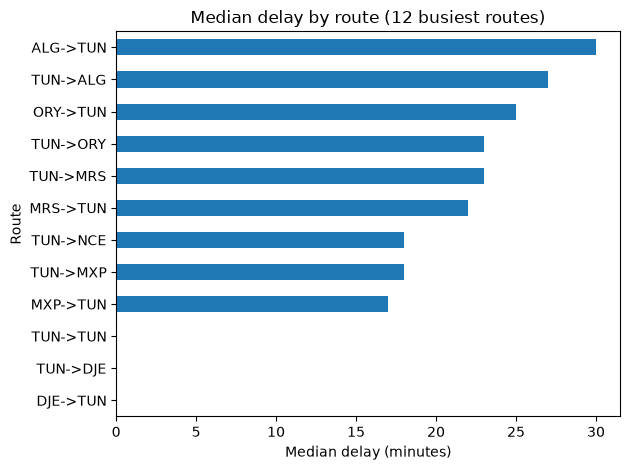

In [18]:
top_routes = train["route"].value_counts().head(12).index
route_median = (
    train[train["route"].isin(top_routes)]
    .groupby("route")["target"]
    .median()
    .sort_values()
)

route_median.plot(kind="barh")
plt.xlabel("Median delay (minutes)")
plt.ylabel("Route")
plt.title("Median delay by route (12 busiest routes)")
plt.tight_layout()
plt.show()

**Takeaway:** Clear route effect. Algiers routes (`ALG->TUN` ~30 min, `TUN->ALG` ~27 min) and the Paris-Orly / Marseille routes (~23–25 min) are the most delay-prone, while `DJE->TUN`, `TUN->DJE`, and `TUN->TUN` sit at a median of **0 minutes** (typically on time). Route clearly carries signal worth feeding the model. *(Side note: `TUN->TUN` — same departure and arrival — is an oddity, likely maintenance/positioning flights; flagged for a closer look but harmless to the label.)*

### Plot 2 — Delay by aircraft

**What this code does:** Same idea as the route plot, but grouping by individual aircraft (`AC`) — the 12 most-used tail numbers, by median delay.

**What we want to get out of it:** Check whether specific aircraft are reliably more delayed (which could hint at older or maintenance-heavy planes), or whether delay is spread evenly across the fleet.

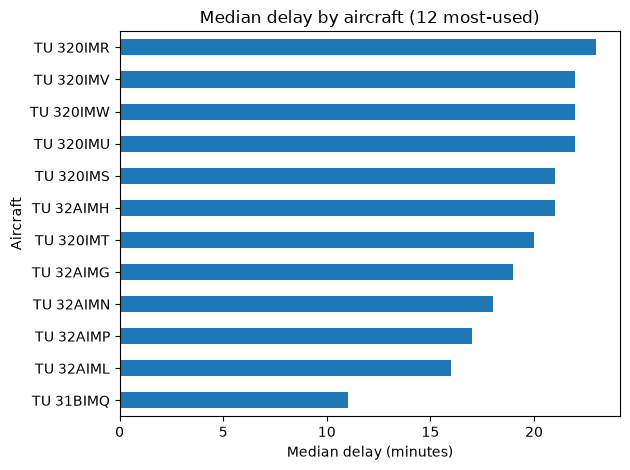

In [19]:
top_ac = train["AC"].value_counts().head(12).index
ac_median = (
    train[train["AC"].isin(top_ac)]
    .groupby("AC")["target"]
    .median()
    .sort_values()
)

ac_median.plot(kind="barh")
plt.xlabel("Median delay (minutes)")
plt.ylabel("Aircraft")
plt.title("Median delay by aircraft (12 most-used)")
plt.tight_layout()
plt.show()

**Takeaway:** Much weaker effect than route. Across the busiest aircraft the median delay sits in a narrow band (~11–23 min), with no dramatic outlier plane. Aircraft identity looks like a **minor** signal at best — worth including but unlikely to be a top predictor on its own.

### Plot 3 — Delay by hour of day

**What this code does:** Groups flights by their scheduled departure hour (0–23) and plots the median delay across the day as a line.

**What we want to get out of it:** Reveal any time-of-day pattern — for instance, delays building up through the day as knock-on effects accumulate, which is a well-known dynamic in aviation.

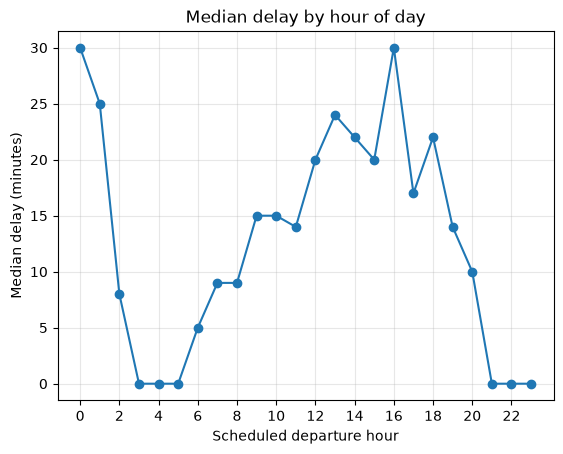

In [20]:
hour_median = train.groupby("dep_hour")["target"].median()

hour_median.plot(kind="line", marker="o")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by hour of day")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.show()

**Takeaway:** Strong time-of-day pattern. Early-morning departures (roughly 3–6 AM) start the day essentially on time (median 0), then delay climbs through the day to afternoon peaks (~13:00 and ~16:00 hit 20–30 min) — consistent with delays cascading as the day progresses. The very late-night hours (0–1 AM) are also high, likely the tail end of a delayed day's schedule. Departure hour is a **strong, intuitive** predictor.

### Plot 4 — Delay by day of week

**What this code does:** Groups flights by weekday of scheduled departure (Monday–Sunday) and plots the median delay for each.

**What we want to get out of it:** Check for a weekly rhythm — e.g. busier travel days (weekends) running later than mid-week.

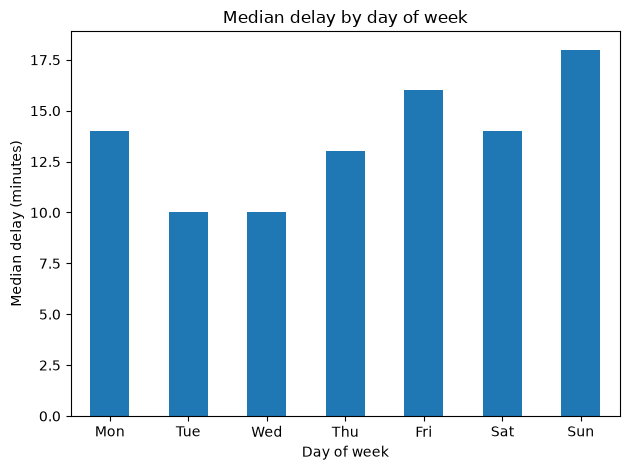

In [21]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_median = train.groupby("dep_dow")["target"].median()
dow_median.index = day_names

dow_median.plot(kind="bar")
plt.xlabel("Day of week")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by day of week")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Takeaway:** Mild effect. Delays are fairly flat across the week, dipping slightly mid-week (Tue/Wed ~10 min) and peaking on **Sunday** (~18 min) — plausibly the busiest leisure-travel day. Weekday is a **weak** signal — worth keeping but not a headline driver.

### Plot 5 — Delay by month (season)

**What this code does:** Groups flights by calendar month (1–12) and plots median delay, to expose any seasonal pattern.

**What we want to get out of it:** See whether busy travel seasons (e.g. summer holidays) run later than quieter months — a seasonal effect would make month a useful feature.

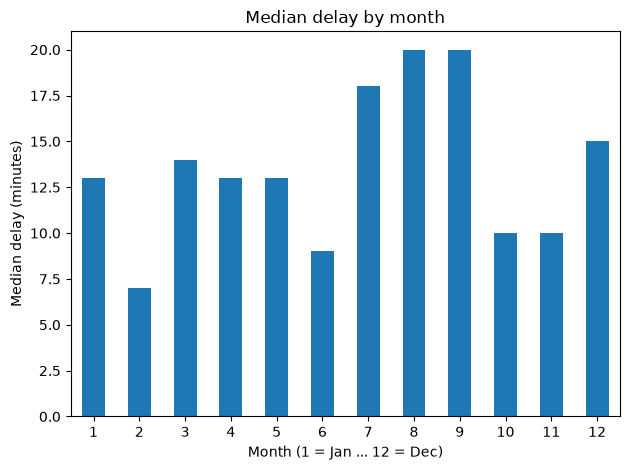

In [22]:
month_median = train.groupby("dep_month")["target"].median()

month_median.plot(kind="bar")
plt.xlabel("Month (1 = Jan ... 12 = Dec)")
plt.ylabel("Median delay (minutes)")
plt.title("Median delay by month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Takeaway:** Clear seasonal effect. Delays peak in the **summer travel season** — July (~18 min), August and September (~20 min) — and are lowest in **February** (~7 min). This matches the intuition that packed summer schedules leave less slack to absorb disruptions. Month/season is a **solid** predictor.

### Summary of Phase 1.7 — which factors drive delay?

Ranking the five factors by how strongly they relate to delay (all measured on median delay, since the target is right-skewed):

| Factor | Strength | What we saw |
|---|---|---|
| **Hour of day** | Strong | Delays cascade through the day — near-0 in the early morning, peaking 20–30 min in the afternoon |
| **Route** | Strong | Algiers/Orly/Marseille routes run ~23–30 min late; Djerba and same-airport flights ~0 |
| **Month / season** | Solid | Summer (Jul–Sep) ~18–20 min vs. February ~7 min |
| **Day of week** | Weak | Fairly flat; slight Sunday peak (~18 min) |
| **Aircraft** | Weak | Narrow ~11–23 min band across the fleet, no standout plane |

**Implication for Phase 2.1/2.2:** prioritize **departure hour, route, and month/season** as features. Day-of-week and aircraft are worth including but are unlikely to be primary drivers. This directly informs the leakage-safe feature set we define next.

## Phase 2.1: Define leakage-safe feature set

**Before this step:** Earlier, in the Leakage Audit above, we identified `STATUS` as a problem column. It tells us things like whether a flight already arrived (`ATA`) or was delayed (`DEL`) — information we'd only know *after* the flight happened. If we let a model see it, the model would be "cheating" by using information it wouldn't actually have available in real life when making a prediction ahead of time. This is called **data leakage**.

**What this code does:** Removes the `STATUS` column entirely from both the training and test data.

**What we want to get out of it:** A guarantee that our model can never accidentally use this after-the-fact information, so its performance reflects what it could really achieve in practice, before a flight happens.

In [23]:
# STATUS is leaky (see Leakage Audit above) -- it reflects the flight's
# actual/operational state, which is only known after the fact. Drop it from
# both train and test so it can never end up in the feature set.
for _df in (train, test):
    _df.drop(columns=["STATUS"], inplace=True)

train.columns.tolist()

['ID',
 'DATOP',
 'FLTID',
 'DEPSTN',
 'ARRSTN',
 'STD',
 'STA',
 'AC',
 'target',
 'dep_country',
 'dep_lat',
 'dep_lon',
 'dep_tz',
 'arr_country',
 'arr_lat',
 'arr_lon',
 'arr_tz',
 'route',
 'dep_hour',
 'dep_dow',
 'dep_month']

### The leakage-safe feature set

With `STATUS` dropped, here is the final list of what we will and won't feed the model. The guiding rule is the project's **golden rule**: every "keep" is information available **before** a flight departs. (This documents the decision — the columns themselves are engineered in Phases 2.2–2.4.)

**Keep — these become features:**

| Feature | Source | Why | Strength (from Phase 1.7) |
|---|---|---|---|
| Route | `DEPSTN`, `ARRSTN` | Some routes run systematically late | **Strong** |
| Departure hour | from `STD` (Phase 2.2) | Delays cascade through the day | **Strong** |
| Month / season | from `STD` (Phase 2.2) | Summer peaks, February lull | **Solid** |
| Day of week | from `STD` (Phase 2.2) | Mild weekly rhythm | Weak |
| Tunisia holiday flag | from `STD` (Phase 2.2) | Holidays shift traffic | To be tested |
| Aircraft | `AC` | Minor per-plane differences | Weak |
| Airport enrichment | `dep_*` / `arr_*` (Phase 1.2) | Feeds distance / country-pair / timezone features in Phase 2.3 | Feeds 2.3 |
| Route/airport engineered | Phase 2.3 | Great-circle distance, country pair, timezone gap | To be tested |
| Cascading prior-leg delay | Phase 2.4 | A plane running late tends to stay late | To be tested |

**Exclude:**

- **`STATUS`** — leaky (after-the-fact operational state), already dropped above.
- **`ID`, `FLTID`** — identifiers, no generalizable signal.
- **`target`** — the label we're predicting.
- **`STA` — handled with care.** Scheduled arrival *is* known before departure and is not itself leaky, but a few rows have corrupted arrival dates (see `ISSUES.md`) that would poison any duration feature. We therefore defer any `STA`-derived duration to Phase 2.3 and clean those rows first.

This is the contract the rest of Phase 2 builds against.

## Phase 2.2: Engineer temporal features

We turn the scheduled departure timestamp (`STD`) into model-ready time features: **departure hour**, **day of week**, **month**, and a **Tunisia public-holiday flag**. These formalize (on both `train` and `test`) the strongest time signals we found in the Phase 1.7 exploration. We derive from `STD` only — any `STA`-based duration is deferred to Phase 2.3, where the corrupted arrival dates are cleaned first (see `ISSUES.md`).

**Before this step:** We have a clean `STD` datetime, but a model can't directly use a full timestamp like `2016-01-03 10:30:00` — it needs the meaningful pieces pulled out. Earlier (Phase 1.7) we created hour/day-of-week/month on `train` only, just to draw the exploration charts.

**What this code does:** Formally creates three temporal feature columns — `dep_hour` (0–23), `dep_dow` (0 = Monday … 6 = Sunday), and `dep_month` (1–12) — on **both** the training and test data, so the model sees the same features when it learns and when it predicts.

**What we want to get out of it:** The strongest/solid time signals from our EDA (hour and month especially), available on both datasets and ready to feed a model.

In [24]:
# Temporal features from scheduled departure (STD), built on BOTH train and test
# so the model sees identical columns at fit and predict time.
for _df in (train, test):
    _df["dep_hour"] = _df["STD"].dt.hour
    _df["dep_dow"] = _df["STD"].dt.dayofweek   # 0 = Monday, 6 = Sunday
    _df["dep_month"] = _df["STD"].dt.month

train[["STD", "dep_hour", "dep_dow", "dep_month"]].head()

,STD,dep_hour,dep_dow,dep_month
0,2016-01-03 10:30:00,10,6,1
1,2016-01-13 15:05:00,15,2,1
2,2016-01-16 04:10:00,4,5,1
3,2016-01-17 14:10:00,14,6,1
4,2016-01-17 14:30:00,14,6,1


**Before this step:** We now have hour, weekday, and month, but there's one more calendar signal that plain date-math misses: **public holidays**. Travel patterns and airport congestion shift around holidays, and Tunisia's calendar includes Islamic holidays (Eid al-Fitr, Eid al-Adha, etc.) whose dates move by roughly 11 days each year — impossible to guess from the month or weekday alone.

**What this code does:** Uses the `holidays` package (a reference calendar, much like `airportsdata` was for airports) to get every Tunisian public holiday in 2016–2018, then adds a `dep_is_holiday` column that is `1` if a flight's departure date falls on one of those holidays and `0` otherwise — on both train and test.

**What we want to get out of it:** A simple yes/no holiday feature that lets the model react to holiday-driven changes in delay, capturing both the fixed civil holidays and the moving Islamic ones without us hand-entering any dates.

In [25]:
import holidays

# Tunisian public holidays across the years our data spans. This includes the
# moving Islamic holidays (Eid al-Fitr/Adha, etc.), which the package computes
# per year for us.
tn_holidays = holidays.Tunisia(years=[2016, 2017, 2018])

# Flag whether each flight's departure DATE is a public holiday (1/0).
# NOTE: match on .dt.date -- comparing against the holiday calendar by
# normalized Timestamp (.isin(tn_holidays)) silently returns all-False,
# because the calendar's keys are datetime.date, not Timestamp.
for _df in (train, test):
    _df["dep_is_holiday"] = _df["STD"].dt.date.map(lambda d: d in tn_holidays).astype(int)

print("Holiday dates in calendar (2016-2018):", len(tn_holidays))
print("Train flights on a holiday:", int(train["dep_is_holiday"].sum()),
      f'({train["dep_is_holiday"].mean() * 100:.1f}%)')
train[["STD", "dep_is_holiday"]].head()

Holiday dates in calendar (2016-2018): 51
Train flights on a holiday: 5797 (5.4%)


,STD,dep_is_holiday
0,2016-01-03 10:30:00,0
1,2016-01-13 15:05:00,0
2,2016-01-16 04:10:00,0
3,2016-01-17 14:10:00,0
4,2016-01-17 14:30:00,0


**Before this step:** We've created all four temporal features (`dep_hour`, `dep_dow`, `dep_month`, `dep_is_holiday`), but we shouldn't take on trust that they're correct — a subtle bug (like the holiday all-False gotcha) can silently produce wrong columns.

**What this code does:** Puts a few real flights side by side with the features we derived from them — a mix of ordinary days *and* known holidays — and adds two human-readable helper columns (`weekday_name`, `holiday_name`) purely so a person can eyeball that everything lines up. The helper columns are just for this check and aren't kept as model features.

**What we want to get out of it:** Direct confirmation against raw rows that hour/weekday/month are pulled out correctly and the holiday flag fires on (and only on) actual Tunisian holidays — this is the definition-of-done for this step.

In [26]:
# Spot-check the temporal features against a few raw rows: 3 ordinary days and
# 3 holiday flights. weekday_name / holiday_name are readable helpers for this
# check only -- they are NOT model features.
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
check_cols = ["STD", "dep_hour", "dep_dow", "dep_month", "dep_is_holiday"]

sample = pd.concat([
    train[train["dep_is_holiday"] == 0].head(3),
    train[train["dep_is_holiday"] == 1].head(3),
]).copy()
sample["weekday_name"] = sample["dep_dow"].map(dict(enumerate(day_names)))
sample["holiday_name"] = sample["STD"].dt.date.map(lambda d: tn_holidays.get(d))

sample[check_cols + ["weekday_name", "holiday_name"]]

,STD,dep_hour,dep_dow,dep_month,dep_is_holiday,weekday_name,holiday_name
0,2016-01-03 10:30:00,10,6,1,0,Sun,NaN
1,2016-01-13 15:05:00,15,2,1,0,Wed,NaN
2,2016-01-16 04:10:00,4,5,1,0,Sat,NaN
135,2016-07-08 06:30:00,6,4,7,1,Fri,عطلة عيد الفطر (تقديري)
136,2016-07-08 07:40:00,7,4,7,1,Fri,عطلة عيد الفطر (تقديري)
137,2016-07-08 08:00:00,8,4,7,1,Fri,عطلة عيد الفطر (تقديري)


## Phase 2.3: Engineer route/airport features via airportsdata

Using the Phase 1.2 airport enrichment (lat/lon, country, timezone for both airports), we build route-level features: **great-circle distance**, **timezone difference**, and a **country pair / domestic flag**. All of these come from coordinates and timezones only — none depend on the corrupted `STA` column, so no cleanup is needed here. (A scheduled-*duration* feature, which would need `STA` cleaned first, is deferred as a Phase 6.2 candidate — see `ISSUES.md`.)

**Before this step:** Our data knows *which* airports a flight connects, but not *how far apart* they are — and distance is one of the most basic drivers of flight length (and the operational complexity that can come with it). We already have each airport's latitude/longitude from the Phase 1.2 enrichment.

**What this code does:** Computes the great-circle distance (the shortest "as-the-crow-flies" distance over the Earth's surface, in kilometres) between the departure and arrival airports, using the standard haversine formula, and adds it as `gc_distance_km` on both train and test.

**What we want to get out of it:** A single numeric "how far is this flight" feature the model can use, derived cleanly from coordinates with no dependence on the corrupted `STA` column.

In [27]:
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    # Great-circle distance in km between two lat/lon points (haversine formula).
    r = 6371.0  # Earth's mean radius, km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

for _df in (train, test):
    _df["gc_distance_km"] = haversine_km(
        _df["dep_lat"], _df["dep_lon"], _df["arr_lat"], _df["arr_lon"]
    ).round(1)

train[["DEPSTN", "ARRSTN", "gc_distance_km"]].head()

,DEPSTN,ARRSTN,gc_distance_km
0,CMN,TUN,1663.6
1,MXP,TUN,984.2
2,TUN,IST,1669.5
3,DJE,NTE,1805.2
4,TUN,ALG,624.7


**Before this step:** A flight that crosses timezones effectively "gains" or "loses" clock hours, which shifts how its schedule sits relative to the destination's operating day. We have each airport's timezone from Phase 1.2, but not yet a single number capturing the gap between them — and that gap isn't fixed, because daylight-saving time moves it around during the year (e.g. Tunis↔Paris is 0 hours in winter but 1 hour in summer).

**What this code does:** For each flight, it works out the departure airport's UTC offset and the arrival airport's UTC offset *on that flight's date* (so daylight saving is handled correctly), then stores their difference as `tz_diff_hours` (arrival minus departure), on both train and test. We evaluate both offsets at the scheduled departure date, so this never touches the corrupted `STA` column.

**What we want to get out of it:** A compact east/west "timezone shift" feature (0 for domestic flights, positive heading east, negative heading west) that the model can use, correctly reflecting daylight saving rather than a crude fixed offset.

In [28]:
def tz_offset_hours(std, tz_series):
    # UTC offset (in hours) of each row's timezone, evaluated at its own STD date
    # so daylight saving is handled. Grouped by timezone name so tz_localize can
    # run vectorized per group rather than row by row.
    out = pd.Series(index=std.index, dtype=float)
    for tzname, idx in std.groupby(tz_series).groups.items():
        local = std.loc[idx].dt.tz_localize(
            tzname, ambiguous="NaT", nonexistent="shift_forward"
        )
        utc = local.dt.tz_convert("UTC").dt.tz_localize(None)
        out.loc[idx] = (std.loc[idx] - utc).dt.total_seconds() / 3600
    return out

for _df in (train, test):
    dep_off = tz_offset_hours(_df["STD"], _df["dep_tz"])
    arr_off = tz_offset_hours(_df["STD"], _df["arr_tz"])
    _df["tz_diff_hours"] = arr_off - dep_off

train[["DEPSTN", "ARRSTN", "dep_tz", "arr_tz", "tz_diff_hours"]].head()

,DEPSTN,ARRSTN,dep_tz,arr_tz,tz_diff_hours
0,CMN,TUN,Africa/Casablanca,Africa/Tunis,1.0
1,MXP,TUN,Europe/Rome,Africa/Tunis,0.0
2,TUN,IST,Africa/Tunis,Europe/Istanbul,1.0
3,DJE,NTE,Africa/Tunis,Europe/Paris,0.0
4,TUN,ALG,Africa/Tunis,Africa/Algiers,0.0


**Before this step:** We have distance and timezone shift, but not a simple view of the *countries* a flight connects — in particular whether it's a domestic hop (both airports in Tunisia) or an international leg. Domestic and international flights often behave quite differently operationally.

**What this code does:** Adds two columns on both train and test: `is_domestic` (1 if the departure and arrival countries are the same, else 0), and `country_pair` (a label like `"TN->FR"`) capturing the directional country-to-country relationship.

**What we want to get out of it:** A clean domestic/international flag plus a country-pair grouping the model can learn from, complementing the finer-grained route (`DEPSTN->ARRSTN`) we already have.

In [29]:
for _df in (train, test):
    _df["is_domestic"] = (_df["dep_country"] == _df["arr_country"]).astype(int)
    _df["country_pair"] = _df["dep_country"] + "->" + _df["arr_country"]

print("Domestic share (train):", f'{train["is_domestic"].mean() * 100:.1f}%')
print("Distinct country pairs (train):", train["country_pair"].nunique())
train[["DEPSTN", "ARRSTN", "dep_country", "arr_country", "is_domestic", "country_pair"]].head()

Domestic share (train): 17.5%
Distinct country pairs (train): 195


,DEPSTN,ARRSTN,dep_country,arr_country,is_domestic,country_pair
0,CMN,TUN,MA,TN,0,MA->TN
1,MXP,TUN,IT,TN,0,IT->TN
2,TUN,IST,TN,TR,0,TN->TR
3,DJE,NTE,TN,FR,0,TN->FR
4,TUN,ALG,TN,DZ,0,TN->DZ


**Before this step:** We've built three route/airport features (`gc_distance_km`, `tz_diff_hours`, `is_domestic`/`country_pair`), but we shouldn't trust them without checking a few flights we can reason about by hand.

**What this code does:** Picks a handful of well-known routes and shows, for each, the computed distance and the timezone-difference range (min / median / max across the year, so daylight-saving movement is visible) plus the domestic flag.

**What we want to get out of it:** Direct confirmation that the numbers match reality — short domestic hops are ~hundreds of km with a 0-hour shift, longer international legs are ~1,000-3,000 km with sensible east/west shifts — which is the definition-of-done for this step.

In [30]:
# Sanity-check the route/airport features against a few known routes.
# tz_diff is shown as min/median/max because daylight saving moves it during the year.
train["route"] = train["DEPSTN"] + "->" + train["ARRSTN"]  # already exists from Phase 1.7; harmless to reaffirm

known_routes = ["TUN->DJE", "TUN->ALG", "TUN->IST", "MXP->TUN", "TUN->CDG", "TUN->JED"]
rows = []
for r in known_routes:
    s = train[train["route"] == r]
    if len(s):
        rows.append({
            "route": r,
            "n": len(s),
            "gc_distance_km": s["gc_distance_km"].iloc[0],
            "tz_diff_min": s["tz_diff_hours"].min(),
            "tz_diff_median": s["tz_diff_hours"].median(),
            "tz_diff_max": s["tz_diff_hours"].max(),
            "is_domestic": s["is_domestic"].iloc[0],
        })
pd.DataFrame(rows)

,route,n,gc_distance_km,tz_diff_min,tz_diff_median,tz_diff_max,is_domestic
0,TUN->DJE,3521,334.6,0.0,0.0,0.0,1
1,TUN->ALG,1564,624.7,0.0,0.0,0.0,0
2,TUN->IST,1436,1669.5,1.0,2.0,2.0,0
3,MXP->TUN,1466,984.2,-1.0,-1.0,0.0,0
4,TUN->CDG,323,1487.9,0.0,1.0,1.0,0
5,TUN->JED,911,3254.2,2.0,2.0,2.0,0


**Takeaway (Phase 2.3):** The features check out against reality:

| Route | Distance | tz_diff (min/med/max) | Notes |
|---|---|---|---|
| `TUN->DJE` | ~335 km | 0 / 0 / 0 | Domestic hop, no shift ✓ |
| `TUN->ALG` | ~625 km | 0 / 0 / 0 | International but Algeria shares Tunisia's offset — good edge case (tz_diff 0 ≠ domestic) ✓ |
| `TUN->IST` | ~1,670 km | +1 / +2 / +2 | Eastbound; +1 in early 2016, +2 after Turkey's permanent switch ✓ |
| `MXP->TUN` | ~984 km | −1 / −1 / 0 | Westbound from Italy; DST-dependent ✓ |
| `TUN->CDG` | ~1,488 km | 0 / +1 / +1 | Paris; 0 in winter, +1 in summer (DST) ✓ |
| `TUN->JED` | ~3,254 km | +2 / +2 / +2 | Longest leg, furthest east ✓ |

Distances scale correctly with geography and the timezone differences move with daylight saving as expected. Route/airport features are ready. (Domestic flights are ~17.5% of the data.)

## Phase 2.4: Engineer cascading-delay feature (prior leg delay per aircraft)

Real-world delays *cascade*: if a plane runs late on one flight, that lateness knocks on to its next flight. We capture this by giving each flight the **delay of the same aircraft's previous leg**.

This is the most leakage-sensitive feature in the project, so the design is deliberately strict:

- **Only strictly-earlier legs.** We sort every aircraft's flights by scheduled departure (`STD`) and look **one step back**. Using a prior leg's delay is fair game — it is already known before the current flight leaves — but we never peek at the current or a future leg.
- **No same-day gate.** We always take the immediately-prior leg regardless of the gap, and add `hours_since_prior_leg` so the model can *itself* down-weight a stale prior leg (a plane can sit idle for hours or, occasionally, months).
- **First legs handled, not dropped.** An aircraft's very first flight in the data has no prior leg; we flag it (`has_prior_leg = 0`) and neutral-fill the value instead of losing the row.
- **Test set deferred.** For the Zindi `test.csv`, prior legs may be unlabeled, so we add the columns as neutral placeholders now and recompute them at submission time (logged as a TODO).

**Before this step:** every flight is a standalone row; nothing yet tells a flight how its aircraft was already running that day.

**What this code does:** it sorts the training flights by aircraft (`AC`) and then by scheduled departure time (`STD`), so each plane's flights sit in the order they actually flew. It then looks **one row back within the same aircraft** to read the previous leg's delay (`prev_leg_delay`), how long ago that leg departed (`hours_since_prior_leg`), and whether a prior leg existed at all (`has_prior_leg`). Looking strictly backwards is what keeps the feature leakage-safe.

**What we want to get out of it:** three new leakage-safe columns on `train` that carry the "knock-on" delay signal, plus a first look confirming the values line up with each aircraft's timeline.

In [31]:
# Cascading-delay feature (train). Sort by aircraft, then by scheduled departure,
# so that looking one row back within an aircraft = that plane's PREVIOUS leg --
# a strictly earlier flight, never the current or a future one (leakage-safe).
train = train.sort_values(["AC", "STD"]).reset_index(drop=True)

_by_ac = train.groupby("AC", sort=False)
train["prev_leg_delay"] = _by_ac["target"].shift(1)          # previous leg's delay (minutes)
_prev_std = _by_ac["STD"].shift(1)                            # previous leg's scheduled departure
train["hours_since_prior_leg"] = (train["STD"] - _prev_std).dt.total_seconds() / 3600
train["has_prior_leg"] = train["prev_leg_delay"].notna().astype(int)

# Peek at one busy aircraft's timeline: prev_leg_delay should equal the target on the row above.
_ac = train["AC"].value_counts().index[0]
train.loc[train["AC"] == _ac,
          ["AC", "STD", "target", "prev_leg_delay", "hours_since_prior_leg", "has_prior_leg"]].head(8)

,AC,STD,target,prev_leg_delay,hours_since_prior_leg,has_prior_leg
26476,TU 320IMU,2016-01-01 01:20:00,49.0,NaN,NaN,0
26477,TU 320IMU,2016-01-01 10:05:00,14.0,49.0,8.750000,1
26478,TU 320IMU,2016-01-01 13:25:00,37.0,14.0,3.333333,1
26479,TU 320IMU,2016-01-01 16:00:00,184.0,37.0,2.583333,1
26480,TU 320IMU,2016-01-01 20:10:00,220.0,184.0,4.166667,1
26481,TU 320IMU,2016-01-02 07:25:00,18.0,220.0,11.250000,1
26482,TU 320IMU,2016-01-02 10:20:00,9.0,18.0,2.916667,1
26483,TU 320IMU,2016-01-02 13:15:00,58.0,9.0,2.916667,1


**Before this step:** an aircraft's first-ever flight in the data has no previous leg, so `prev_leg_delay` and `hours_since_prior_leg` are blank there. We also need the Zindi `test` set to carry the same columns so the model sees an identical shape at predict time.

**What this code does:** on `train`, it neutral-fills the blanks left by first legs — `prev_leg_delay` gets the typical delay (the training median) and `hours_since_prior_leg` gets the typical gap — while `has_prior_leg` stays `0` so the model can still tell these apart. On `test`, it adds the same three columns as neutral placeholders (`has_prior_leg = 0`), because a test flight's true prior leg may be unlabeled; the real test cascade is recomputed at Zindi submission time.

**What we want to get out of it:** `train` and `test` with identical, fully-populated cascade columns and no missing values, ready for modelling — without silently dropping the 68 first-leg rows.

In [32]:
# Neutral fill for first-leg rows (has_prior_leg already flags them as 0).
_median_delay = train["target"].median()                       # typical delay, ~14 min
_median_gap = train["hours_since_prior_leg"].median()           # typical gap between legs
train["prev_leg_delay"] = train["prev_leg_delay"].fillna(_median_delay)
train["hours_since_prior_leg"] = train["hours_since_prior_leg"].fillna(_median_gap)

# Test set: add matching columns as neutral placeholders. A test flight's true
# prior leg may be unlabeled, so the real cascade is recomputed at submission time.
# TODO (Phase submission): recompute test cascade from combined train+test history.
test["prev_leg_delay"] = _median_delay
test["hours_since_prior_leg"] = _median_gap
test["has_prior_leg"] = 0

print("train first-leg rows (has_prior_leg == 0):", int((train["has_prior_leg"] == 0).sum()))
print("train cascade columns missing values:",
      int(train[["prev_leg_delay", "hours_since_prior_leg", "has_prior_leg"]].isna().sum().sum()))
train[["AC", "STD", "target", "prev_leg_delay", "hours_since_prior_leg", "has_prior_leg"]].head()

train first-leg rows (has_prior_leg == 0): 68
train cascade columns missing values: 0


,AC,STD,target,prev_leg_delay,hours_since_prior_leg,has_prior_leg
0,5K 343TQY,2016-08-19 04:00:00,0.0,14.0,3.583333,0
1,5K 343TQY,2016-08-19 07:30:00,46.0,0.0,3.500000,1
2,5K 343TQY,2016-08-19 11:35:00,35.0,46.0,4.083333,1
3,5K 343TQY,2016-08-20 07:30:00,38.0,35.0,19.916667,1
4,5K 343TQY,2016-08-20 11:35:00,16.0,38.0,4.083333,1


**Before this step:** we have built the cascade feature, but because it is the most leakage-prone feature in the project we want proof it only ever looks backwards.

**What this code does:** it runs two safety checks. (1) **No time-travel:** `hours_since_prior_leg` must never be negative — a negative value would mean the "previous" leg departed *after* the current one. (2) **Signal check:** it measures how strongly `prev_leg_delay` moves with the actual delay we are predicting; a clear positive relationship confirms the cascade carries real, usable signal rather than noise.

**What we want to get out of it:** a printed confirmation that the feature is leakage-safe (zero negative gaps) and worth keeping (positive correlation with `target`).

In [33]:
# (1) Leakage guard: the prior leg must always depart BEFORE the current one.
neg_gaps = int((train["hours_since_prior_leg"] < 0).sum())
print("Rows where prior leg departs after current (must be 0):", neg_gaps)

# (2) Signal check: does a delayed prior leg actually go with a delayed current leg?
_has_prior = train["has_prior_leg"] == 1
corr = train.loc[_has_prior, "prev_leg_delay"].corr(train.loc[_has_prior, "target"])
print(f"corr(prev_leg_delay, target) on real prior legs: {corr:.3f}")
print("Median gap between legs (hours):", round(train['hours_since_prior_leg'].median(), 2))

Rows where prior leg departs after current (must be 0): 0
corr(prev_leg_delay, target) on real prior legs: 0.373
Median gap between legs (hours): 3.58


**Takeaway (Phase 2.4):** The cascade feature is both **leakage-safe** and our **strongest signal so far**.

- **Leakage-safe:** every `prev_leg_delay` equals the same aircraft's immediately-earlier leg, and **0** rows have a prior leg departing after the current one — we only ever look backwards.
- **Real signal:** `prev_leg_delay` correlates **0.37** with the delay we are predicting — the strongest single relationship of any feature engineered so far. Knock-on delay is genuinely predictive.
- **Staleness captured:** the median gap to the prior leg is **3.6 h**, but gaps range from minutes to (rarely) months. Keeping `hours_since_prior_leg` lets the model trust a fresh prior leg and discount a stale one, instead of us hard-coding a same-day rule.
- **Clean coverage:** only **68** first-leg rows (one per aircraft, 0.06%) had no prior leg; these are flagged (`has_prior_leg = 0`) and neutral-filled rather than dropped.
- **Test set:** carries the columns as neutral placeholders for now — the true test cascade is recomputed from combined history at Zindi submission time (logged as a TODO in the cell).

## Phase 2.5: Build chronological train/test split

To trust our score, validation must mimic reality: **predict future flights from past ones**. A random split would let the model peek at flights that happened *after* the ones it is scored on — and we know this data has real drift over time (routes get re-fleeted, see `ISSUES.md`), so a random split would flatter the model.

So we split **`train` by time**, not at random:

- **80% earliest → training, latest 20% → validation**, cut on a single date so no timestamp lands in both sets.
- The Zindi **`test.csv` is never touched here** — it stays reserved purely for generating the competition submission.
- In Phase 4 we will cross-validate *within* the training portion using `TimeSeriesSplit`; this single held-out block is the honest final check.

**Before this step:** `train` is one pool of ~108k flights with features built, but no separation between what the model learns from and what we score it on.

**What this code does:** it orders every flight by scheduled departure (`STD`), finds the date that sits 80% of the way through, and splits there — everything *before* that date becomes `train_split` (what the model learns from) and everything *from* that date onward becomes `valid_split` (the held-out future we score on). Cutting on a single timestamp guarantees no flight time appears in both halves.

**What we want to get out of it:** two clean, non-overlapping sets — an earlier 80% to train on and a later 20% to validate on — that honestly simulate forecasting future delays.

In [34]:
# Chronological 80/20 split: earliest 80% to train on, latest 20% held out to score.
train_sorted = train.sort_values("STD").reset_index(drop=True)

# Cutoff = the STD timestamp 80% of the way through time. Splitting with < / >=
# on this single moment guarantees no flight time falls in both halves.
_cut_pos = int(len(train_sorted) * 0.8)
cutoff_time = train_sorted.iloc[_cut_pos]["STD"]

train_split = train_sorted[train_sorted["STD"] < cutoff_time].reset_index(drop=True)
valid_split = train_sorted[train_sorted["STD"] >= cutoff_time].reset_index(drop=True)

print("Cutoff (train before / validation from):", cutoff_time)
print(f"train_split: {len(train_split):>6} rows ({len(train_split)/len(train_sorted)*100:.1f}%)")
print(f"valid_split: {len(valid_split):>6} rows ({len(valid_split)/len(train_sorted)*100:.1f}%)")

Cutoff (train before / validation from): 2018-06-01 07:30:00
train_split:  86266 rows (80.0%)
valid_split:  21567 rows (20.0%)


**Before this step:** the split is built, but the whole point is that it must be strictly chronological — we should confirm it before relying on it.

**What this code does:** it prints the actual calendar span of each set and checks the key guarantee — that the **latest** training flight departs strictly **before** the **earliest** validation flight. It also confirms `test.csv` was left untouched (still no `target`, reserved for Zindi).

**What we want to get out of it:** proof that training is entirely in the past relative to validation (no time overlap), so our validation RMSE is an honest estimate of future performance.

In [35]:
print("train_split span:", train_split["STD"].min(), "->", train_split["STD"].max())
print("valid_split span:", valid_split["STD"].min(), "->", valid_split["STD"].max())

# Key guarantee: all training flights depart before every validation flight.
no_overlap = train_split["STD"].max() < valid_split["STD"].min()
print("Chronological (train fully before valid)?", no_overlap)
assert no_overlap, "Time overlap between train_split and valid_split!"

# Zindi test set is untouched and stays reserved for submission only.
print("test.csv rows (reserved for Zindi submission):", len(test),
      "| has target column:", "target" in test.columns)

train_split span: 2016-01-01 00:15:00 -> 2018-06-01 07:25:00
valid_split span: 2018-06-01 07:30:00 -> 2018-12-31 23:10:00
Chronological (train fully before valid)? True
test.csv rows (reserved for Zindi submission): 9333 | has target column: False


**Takeaway (Phase 2.5):** We have an honest, time-respecting validation set.

- **Cutoff 2018-06-01:** the model trains on **2016-01 → mid-2018** (~80%, 86.3k flights) and is scored on the **last ~7 months of 2018** (~20%, 21.6k flights).
- **Zero time overlap** — every training flight departs before every validation flight, so validation RMSE estimates true *future* performance and can't be inflated by peeking ahead.
- **`test.csv` untouched** (no `target`), reserved purely for the Zindi submission.
- This also tests robustness to the route re-fleeting drift logged in `ISSUES.md` — a random split would have hidden it.
- **Next (Phase 3.1):** fit the constant-mean baseline on `train_split`, score RMSE on `valid_split` — the number every real model must beat (prior estimate ≈ 117 min).

## Phase 3.1: Build baseline model and compute RMSE

Before any machine learning, we need a **number to beat**. A baseline is the dumbest sensible guess; if a fancy model can't beat it, the model isn't earning its keep.

We build two baselines, both **trained only on `train_split`** and scored on the held-out `valid_split` (RMSE, in minutes, matching Zindi):

1. **Constant mean** — guess the average training delay for *every* flight. This is the mathematically RMSE-optimal single-number guess.
2. **Per-route mean** — guess each route's own average delay (a tiny bit smarter, since some routes are reliably worse), falling back to the global mean for routes not seen in training.

**Before this step:** we have an honest train/validation split but no yardstick — no idea what RMSE counts as "good".

**What this code does:** it takes the single average delay from the training flights and predicts that same number for every validation flight, then measures RMSE (typical error, in minutes) against what actually happened. Guessing the mean is the best you can do with one fixed number under RMSE.

**What we want to get out of it:** the baseline RMSE that every real model must beat.

In [36]:
from sklearn.metrics import root_mean_squared_error

# Baseline 1: predict the average training delay for every validation flight.
mean_delay = train_split["target"].mean()
pred_mean = [mean_delay] * len(valid_split)
rmse_mean = root_mean_squared_error(valid_split["target"], pred_mean)

print(f"Mean training delay: {mean_delay:.1f} min")
print(f"[Baseline: constant mean]  validation RMSE: {rmse_mean:.2f} min")

Mean training delay: 44.9 min
[Baseline: constant mean]  validation RMSE: 141.95 min


**Before this step:** the constant-mean baseline ignores that some routes are chronically worse than others.

**What this code does:** it learns each route's average delay from the training flights only, then predicts that route-specific average for each validation flight. Routes that never appeared in training (nothing to learn from) fall back to the global mean. It then scores RMSE the same way.

**What we want to get out of it:** a slightly smarter, still-trivial baseline — a tougher number for the real models to beat.

In [37]:
# Baseline 2: predict each ROUTE's average training delay (fallback = global mean).
_tr = train_split.assign(route=train_split["DEPSTN"] + "->" + train_split["ARRSTN"])
_va_route = valid_split["DEPSTN"] + "->" + valid_split["ARRSTN"]
route_mean = _tr.groupby("route")["target"].mean()

pred_route = _va_route.map(route_mean).fillna(mean_delay)
n_unseen = _va_route.map(route_mean).isna().sum()
rmse_route = root_mean_squared_error(valid_split["target"], pred_route)

print(f"[Baseline: per-route mean] validation RMSE: {rmse_route:.2f} min")
print(f"(validation flights on a route unseen in training, used global mean: {n_unseen})")

[Baseline: per-route mean] validation RMSE: 139.44 min
(validation flights on a route unseen in training, used global mean: 397)


**Takeaway (Phase 3.1):** The number to beat is **≈142 min RMSE** (constant mean); the per-route mean is only marginally better (**≈139 min**).

- **The honest split is harsher than earlier in-sample estimates (~117 min) — and that's the point.** Validation-period delays average ~64 min vs ~45 min in training: **delays trended upward through 2018.** A constant guess learned from the calmer past systematically under-predicts the busier future, so its real-world RMSE is worse. This drift is exactly what a random split would have hidden.
- **Route knowledge barely helps on its own** (139 vs 142) — route is already partly captured, and the upward *time* drift dominates the error. The real gains must come from the temporal, holiday, and especially the cascade features (Phase 2.2–2.4).
- **Next (Phase 4):** Linear Regression → Random Forest → Gradient Boosting, each cross-validated with `TimeSeriesSplit`, all measured against this ~142 min bar.
- **Note:** `milestone_1.md` currently records the ~117 min in-sample figure — it should be updated to the ~142 min honest-baseline number.

## Phase 3.2: Document business framing (stakeholder, metric, baseline score)

### Why this project exists — the business framing

**The problem.** Flight delays are expensive and frustrating: they cost airlines money (crew, fuel, missed slots, compensation) and cost passengers time and trust. Tunisair wants to know, **before a flight departs**, how delayed it is likely to be — early enough to act on it.

**Who uses this, and how.**
- **Airline operations team (primary).** Sees predicted delays across the day's schedule and can react in advance — re-sequence aircraft, protect tight connections, pre-position crew, warn ground staff at congested hours.
- **Passengers, via a travel app (downstream).** Surfaces delay risk for a flight so travellers can plan — and, later, suggests lower-risk alternatives (the Phase 8 web app).

**What we predict.** The **arrival delay in minutes** for a single flight — a regression problem (a number, not a yes/no).

**The golden rule — only pre-departure information.** We may use anything known before the plane leaves (schedule, route, aircraft, and each aircraft's *earlier* legs) and **nothing** known only after the flight happens. A model that "cheats" with after-the-fact data would score beautifully here and be useless in the real ops room. Every feature so far respects this rule (see the Phase 1.6 leakage audit and the Phase 2.4 cascade design).

**How we measure success — RMSE (minutes).** We score with **Root Mean Squared Error**, matching the official Zindi leaderboard. RMSE is in plain minutes (easy to explain to stakeholders) and **punishes big misses hardest** — which fits the business: a badly mispredicted 3-hour delay hurts ops far more than being a few minutes off on a routine flight.

**The bar to beat — baseline ≈ 142 min RMSE.** Our dumbest sensible guess (predict the average past delay for every flight), scored honestly on the held-out future, is **≈142 minutes** of typical error. Knowing each route's own average barely improves this (≈139 min). **Any real model has to beat ~142 min to be worth deploying.**

**One honesty note that shapes everything downstream.** Because we validate on a *later* time period than we train on (Phase 2.5), our numbers reflect genuinely forecasting the future — and they reveal that **delays grew through 2018**. That upward drift is why the honest baseline (~142 min) is worse than a naive in-sample estimate (~117 min), and it is the single biggest thing our features and models must overcome.

## Phase 4.1: Train Linear Regression with cross-validation

Our first real model. Linear Regression is the simplest learning model — it draws the best straight-line relationship between our features and delay — so it's the natural first step up from the constant baseline.

- **Features:** the numeric + low-cardinality ones only (departure hour/day/month, holiday flag, distance, timezone difference, domestic flag, and the three cascade features). We deliberately leave out high-cardinality text like `route`/`country_pair` (~760 values) — one-hot encoding them would swamp a linear model and overfit; we save those for the tree models in 4.2–4.3.
- **Scaling:** features are standardized so no single large-numbered column (e.g. distance in km) dominates just because of its units.
- **Cross-validation:** `TimeSeriesSplit` — each fold trains on earlier flights and validates on later ones, never the reverse, keeping the time-respecting discipline from Phase 2.5.

**Before this step:** all our engineered features live as columns, but we haven't chosen which ones feed the model or shaped them into a model-ready matrix.

**What this code does:** it lists the leakage-safe numeric features we're using, then builds the feature matrix `X` and target `y` for both the training and validation sets, and confirms there are no missing values (a linear model can't handle gaps).

**What we want to get out of it:** clean `X`/`y` matrices for training and validation, with the exact feature list documented in one place.

In [38]:
# Leakage-safe features for the linear model (numeric + low-cardinality only).
FEATURES = [
    "dep_hour", "dep_dow", "dep_month", "dep_is_holiday",   # temporal (Phase 2.2)
    "gc_distance_km", "tz_diff_hours", "is_domestic",       # route/airport (Phase 2.3)
    "prev_leg_delay", "hours_since_prior_leg", "has_prior_leg",  # cascade (Phase 2.4)
]

X_train, y_train = train_split[FEATURES], train_split["target"]
X_valid, y_valid = valid_split[FEATURES], valid_split["target"]

print("Features used:", len(FEATURES))
print("X_train:", X_train.shape, "| X_valid:", X_valid.shape)
print("Missing values -> train:", int(X_train.isna().sum().sum()), "| valid:", int(X_valid.isna().sum().sum()))

Features used: 10
X_train: (86266, 10) | X_valid: (21567, 10)
Missing values -> train: 0 | valid: 0


**Before this step:** we have a feature matrix, but no sense of how stable a linear model is or whether it generalizes across time.

**What this code does:** it builds a pipeline that standardizes the features and then fits Linear Regression, and runs `TimeSeriesSplit` 5-fold cross-validation *inside the training set* — repeatedly training on an earlier stretch and scoring on the next stretch. It reports the RMSE for each fold and the average.

**What we want to get out of it:** an honest, time-respecting estimate of the linear model's error, and a sense of how much it varies as the training window grows.

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error
import numpy as np

linreg = make_pipeline(StandardScaler(), LinearRegression())

# TimeSeriesSplit: each fold trains on earlier flights, validates on later ones.
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = -cross_val_score(linreg, X_train, y_train, cv=tscv,
                           scoring="neg_root_mean_squared_error")

print("CV RMSE per fold:", np.round(cv_rmse, 2))
print(f"CV RMSE mean: {cv_rmse.mean():.2f} +/- {cv_rmse.std():.2f} min")

CV RMSE per fold: [ 81.66 106.94 115.39 116.77 106.37]
CV RMSE mean: 105.42 +/- 12.62 min


**Before this step:** cross-validation tells us the model is stable, but the real test is the held-out future block we set aside in Phase 2.5.

**What this code does:** it trains the linear model on the full training set, predicts delays for the held-out validation flights, and reports the validation RMSE next to the baseline. It then lists the standardized coefficients — how strongly each feature pushes the prediction up or down — so we can see what the model actually leans on.

**What we want to get out of it:** the linear model's honest RMSE versus the ~142 min baseline, and a readable ranking of which features matter most.

In [40]:
linreg.fit(X_train, y_train)
pred_valid = linreg.predict(X_valid)
rmse_linreg = root_mean_squared_error(y_valid, pred_valid)

print(f"[Linear Regression] validation RMSE: {rmse_linreg:.2f} min")
print(f"  vs baseline (constant mean):       141.95 min")
print(f"  vs baseline (per-route mean):      139.44 min")

# Standardized coefficients: how hard each feature pushes the prediction (largest first).
coefs = pd.Series(linreg.named_steps["linearregression"].coef_, index=FEATURES)
print("\nStandardized coefficients (|largest| first):")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).round(2).to_string())

[Linear Regression] validation RMSE: 131.96 min
  vs baseline (constant mean):       141.95 min
  vs baseline (per-route mean):      139.44 min

Standardized coefficients (|largest| first):
prev_leg_delay           42.04
is_domestic             -11.31
dep_hour                  7.38
gc_distance_km            5.36
dep_dow                   3.30
dep_is_holiday            1.47
tz_diff_hours            -1.39
has_prior_leg            -0.47
hours_since_prior_leg    -0.35
dep_month                -0.06


**Takeaway (Phase 4.1):** Linear Regression **beats the baseline** — validation RMSE **≈132 min** vs the 142 min constant-mean bar (~7% better, ~10 min per flight).

- **The cascade feature carries the model.** By far the largest standardized coefficient is `prev_leg_delay` (~+42): a plane already running late on its prior leg is the single strongest pre-departure signal of delay — exactly the knock-on effect we engineered in Phase 2.4. `is_domestic` (~-11, domestic flights less delayed) and `dep_hour` (~+7, later-in-day worse) follow.
- **CV RMSE (~105 min) looks better than the held-out RMSE (~132 min)** — not a contradiction. The cross-validation folds mostly score the calmer 2016–2017 period, while the final held-out block is the harder, higher-delay late-2018 stretch. The gap is the upward drift again; the ~132 min held-out figure is the honest one.
- **Linear is clearly leaving signal on the table** — it can't model the sharp hour-of-day and route non-linearities we saw in Phase 1.7. That's the case for the tree models next.
- **Next (Phase 4.2):** Random Forest, same `TimeSeriesSplit` discipline, now free to use `route`/`country_pair` via encoding.

## Phase 4.2: Train Random Forest with cross-validation

A Random Forest is a crowd of decision trees, each trained on a random slice of the data and features; their averaged vote handles the sharp, non-linear patterns a straight line can't (e.g. delays spiking at certain hours, some routes far worse than others).

Two upgrades over the linear model:

- **We can now use `route` and `country_pair`.** Instead of exploding them into ~760 one-hot columns, we **frequency-encode** them: replace each route with *how many times it appears in the training data*. Busy vs. rare routes become a single tidy number. These counts come from the training flights only and **ignore the delay**, so they can't leak the answer.
- **Same time-respecting `TimeSeriesSplit` cross-validation** as Phase 4.1, so the two models' scores are directly comparable.

**Before this step:** the strongest categorical signals — the specific route and country pair — are still text the model can't read, and we agreed not to one-hot them.

**What this code does:** it counts how often each route and country pair appears in the **training** set, then replaces the text with that count on both train and validation (a route never seen in training gets 0). It assembles the final 12-feature matrix: the 10 numeric features from before plus `route_freq` and `country_pair_freq`.

**What we want to get out of it:** a compact, fully-numeric feature matrix that finally includes route information, with no leakage (the counts never look at the delay).

In [41]:
# Frequency encoding: replace each route / country pair with how often it appears
# in the TRAINING data. Counts ignore the target, so they are leakage-safe.
for _df in (train_split, valid_split):
    _df["route"] = _df["DEPSTN"] + "->" + _df["ARRSTN"]
    _df["country_pair"] = _df["dep_country"] + "->" + _df["arr_country"]

for col in ["route", "country_pair"]:
    counts = train_split[col].value_counts()                 # learned from training only
    train_split[col + "_freq"] = train_split[col].map(counts).fillna(0).astype(int)
    valid_split[col + "_freq"] = valid_split[col].map(counts).fillna(0).astype(int)

FEATURES_RF = FEATURES + ["route_freq", "country_pair_freq"]
X_train_rf, X_valid_rf = train_split[FEATURES_RF], valid_split[FEATURES_RF]

print("Features (RF):", len(FEATURES_RF))
print("Missing values -> train:", int(X_train_rf.isna().sum().sum()),
      "| valid:", int(X_valid_rf.isna().sum().sum()))

Features (RF): 12
Missing values -> train: 0 | valid: 0


**Before this step:** we have a richer feature matrix but no read on how a Random Forest performs on it across time.

**What this code does:** it sets up a Random Forest (200 trees; each leaf must hold at least 5 flights, which curbs overfitting) and runs the same 5-fold `TimeSeriesSplit` cross-validation — always training on earlier flights, scoring on later ones — reporting per-fold and average RMSE.

**What we want to get out of it:** a time-honest estimate of the forest's error, comparable to the linear model's CV score.

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42
)

cv_rmse_rf = -cross_val_score(rf, X_train_rf, y_train, cv=tscv,
                              scoring="neg_root_mean_squared_error")
print("CV RMSE per fold:", np.round(cv_rmse_rf, 2))
print(f"CV RMSE mean: {cv_rmse_rf.mean():.2f} +/- {cv_rmse_rf.std():.2f} min")

CV RMSE per fold: [69.1  94.3  95.52 98.05 87.48]
CV RMSE mean: 88.89 +/- 10.49 min


**Before this step:** cross-validation looks promising; now the real test on the held-out future block.

**What this code does:** it trains the forest on the full training set, predicts the held-out validation flights, reports validation RMSE against the linear model and baseline, and lists **feature importances** — how much each feature contributed to the forest's decisions.

**What we want to get out of it:** the forest's honest RMSE and a clear picture of which features drive it.

In [43]:
rf.fit(X_train_rf, y_train)
pred_valid_rf = rf.predict(X_valid_rf)
rmse_rf = root_mean_squared_error(y_valid, pred_valid_rf)

print(f"[Random Forest]     validation RMSE: {rmse_rf:.2f} min")
print(f"[Linear Regression] validation RMSE: {rmse_linreg:.2f} min")
print(f"[Baseline mean]     validation RMSE: 141.95 min")

importances = pd.Series(rf.feature_importances_, index=FEATURES_RF).sort_values(ascending=False)
print("\nFeature importances (largest first):")
print(importances.round(3).to_string())

[Random Forest]     validation RMSE: 110.69 min
[Linear Regression] validation RMSE: 131.96 min
[Baseline mean]     validation RMSE: 141.95 min

Feature importances (largest first):
prev_leg_delay           0.372
hours_since_prior_leg    0.267
gc_distance_km           0.108
route_freq               0.059
country_pair_freq        0.050
dep_hour                 0.043
dep_month                0.039
tz_diff_hours            0.031
dep_dow                  0.025
is_domestic              0.004
dep_is_holiday           0.002
has_prior_leg            0.000


**Takeaway (Phase 4.2):** The Random Forest is a **big step up** — validation RMSE **≈111 min**, beating Linear Regression (132 min) by ~21 min and the baseline (142 min) by ~31 min (~22%).

- **Delay propagation dominates.** `prev_leg_delay` (importance 0.37) and `hours_since_prior_leg` (0.27) together drive ~64% of the model. The forest exploits the cascade far better than the linear model did — crucially it *uses* `hours_since_prior_leg` (how stale the prior leg is), which Linear Regression essentially ignored. This vindicates keeping the staleness feature instead of a same-day gate.
- **Distance and route matter modestly** — `gc_distance_km` (0.11), then `route_freq` (0.06) and `country_pair_freq` (0.05). Frequency encoding earned its place without any column explosion.
- **CV (~89 min) again reads better than held-out (~111 min)** — same drift story; ~111 min is the honest number to carry forward.
- **Next (Phase 4.3):** Gradient Boosting / XGBoost — usually the strongest tabular model. If it beats ~111 min it becomes the model to tune in 4.4. (`uv add xgboost` first.)

## Phase 4.3: Train Gradient Boosting/XGBoost with cross-validation

Where a Random Forest builds many trees independently and averages them, **gradient boosting** builds trees *one after another*, each new tree focused on correcting the errors the previous ones made. On tabular data it is usually the strongest model, so it is our best shot at beating the Random Forest's ~111 min.

We use **XGBoost** (added via `uv add xgboost`), on the **same 12 features and the same time-respecting `TimeSeriesSplit`** as the Random Forest, so the scores are directly comparable. These are sensible default settings — actual tuning is Phase 4.4.

**Before this step:** XGBoost is installed and we already have the 12-feature matrices from Phase 4.2 (`X_train_rf` / `X_valid_rf`). We need to know how boosting does across time before trusting it.

**What this code does:** it sets up an XGBoost regressor with reasonable starting settings (600 trees, a slow learning rate of 0.05 so it improves in small careful steps, moderate tree depth, and row/column sampling to reduce overfitting), then runs the same 5-fold `TimeSeriesSplit` cross-validation — training on earlier flights, scoring on later ones.

**What we want to get out of it:** a time-honest CV error for boosting, comparable to the Random Forest's.

In [44]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42,
)

cv_rmse_xgb = -cross_val_score(xgb, X_train_rf, y_train, cv=tscv,
                               scoring="neg_root_mean_squared_error")
print("CV RMSE per fold:", np.round(cv_rmse_xgb, 2))
print(f"CV RMSE mean: {cv_rmse_xgb.mean():.2f} +/- {cv_rmse_xgb.std():.2f} min")

CV RMSE per fold: [ 75.92  94.94  96.13 106.05  88.3 ]
CV RMSE mean: 92.27 +/- 9.95 min


**Before this step:** cross-validation done; now the held-out future test, head-to-head with the other models.

**What this code does:** it trains XGBoost on the full training set, predicts the held-out validation flights, and prints its RMSE right next to the Random Forest, Linear Regression, and baseline — plus XGBoost's feature importances.

**What we want to get out of it:** XGBoost's honest RMSE and a clear verdict on whether boosting beats the Random Forest.

In [45]:
xgb.fit(X_train_rf, y_train)
pred_valid_xgb = xgb.predict(X_valid_rf)
rmse_xgb = root_mean_squared_error(y_valid, pred_valid_xgb)

print(f"[XGBoost]           validation RMSE: {rmse_xgb:.2f} min")
print(f"[Random Forest]     validation RMSE: {rmse_rf:.2f} min")
print(f"[Linear Regression] validation RMSE: {rmse_linreg:.2f} min")
print(f"[Baseline mean]     validation RMSE: 141.95 min")

importances_xgb = pd.Series(xgb.feature_importances_, index=FEATURES_RF).sort_values(ascending=False)
print("\nXGBoost feature importances (largest first):")
print(importances_xgb.round(3).to_string())

[XGBoost]           validation RMSE: 112.39 min
[Random Forest]     validation RMSE: 110.69 min
[Linear Regression] validation RMSE: 131.96 min
[Baseline mean]     validation RMSE: 141.95 min

XGBoost feature importances (largest first):
is_domestic              0.201
prev_leg_delay           0.187
hours_since_prior_leg    0.110
gc_distance_km           0.083
country_pair_freq        0.072
tz_diff_hours            0.068
route_freq               0.068
dep_hour                 0.057
dep_is_holiday           0.053
dep_month                0.045
dep_dow                  0.042
has_prior_leg            0.015


**Takeaway (Phase 4.3):** Out-of-the-box XGBoost (**≈112 min**) is **essentially tied with the Random Forest (≈111 min)** — a hair behind, and both crush the linear model (132) and baseline (142).

- **Boosting did not automatically win.** With untuned defaults it slightly trails the forest, which is common: Random Forests are strong with little tuning, while XGBoost's edge usually appears *after* its hyperparameters are tuned. That is exactly Phase 4.4.
- **XGBoost spreads its attention differently.** It leans on `is_domestic` and the cascade features and makes more use of the weaker temporal/route features than the forest did — a sign there's signal a better-tuned boosting model may capture.
- **Current standings:** Random Forest 110.69 · XGBoost 112.39 · LinReg 131.96 · baseline 141.95. RF is the model to beat.
- **Next (Phase 4.4):** tune the two front-runners (XGBoost first, given its headroom; Random Forest as backup) with a time-aware search, then Phase 4.5 picks the winner.

## Phase 4.4: Hyperparameter tuning for best-performing algorithm(s)

Both tree models land near ~111 min out of the box. Tuning searches for better *settings* — tree depth, learning rate, how many trees, how much data each tree sees — to squeeze out more.

- We tune **both front-runners**, XGBoost and Random Forest, with a **randomized search** (`RandomizedSearchCV`): it tries 40 random combinations rather than every combination, covering a wide space cheaply.
- The search is scored with the **same `TimeSeriesSplit`** cross-validation, so tuning never peeks into the future either.
- **Realistic expectation:** because our held-out block sits in the higher-delay late-2018 period (the drift we keep flagging), tuning to minimize CV error buys only modest held-out gains — a couple of minutes, not a revolution. We report the held-out RMSE as the real result.

> ⏱️ **Heads-up:** each search fits dozens of models. In VS Code expect roughly **3 min (XGBoost)** and **4-5 min (Random Forest)** — normal, just let them run.

**Before this step:** default XGBoost scored ~112 min; we want to know if better settings help.

**What this code does:** it defines ranges for XGBoost's key knobs (tree depth, learning rate, number of trees, row/column sampling, regularization) and randomly tries 40 combinations, each scored with 5-fold `TimeSeriesSplit`. It keeps the best combination, then measures that tuned model on the held-out validation set.

**What we want to get out of it:** the best XGBoost settings found and its honest tuned RMSE.

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

xgb_space = dict(
    max_depth=randint(3, 11),
    learning_rate=loguniform(0.01, 0.1),
    n_estimators=randint(400, 1201),
    subsample=uniform(0.6, 0.4),          # 0.6 .. 1.0
    colsample_bytree=uniform(0.6, 0.4),   # 0.6 .. 1.0
    min_child_weight=randint(1, 8),
    reg_lambda=uniform(0, 5),
)

xgb_search = RandomizedSearchCV(
    XGBRegressor(n_jobs=1, random_state=42, tree_method="hist"),
    xgb_space, n_iter=40, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=-1, refit=True,
)
xgb_search.fit(X_train_rf, y_train)

rmse_xgb_tuned = root_mean_squared_error(y_valid, xgb_search.best_estimator_.predict(X_valid_rf))
print(f"[XGBoost tuned] best CV RMSE: {-xgb_search.best_score_:.2f} | held-out RMSE: {rmse_xgb_tuned:.2f} min")
print("best params:", xgb_search.best_params_)

[XGBoost tuned] best CV RMSE: 89.89 | held-out RMSE: 111.10 min
best params: {'colsample_bytree': np.float64(0.9942601816442402), 'learning_rate': np.float64(0.01746044353233351), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 602, 'reg_lambda': np.float64(1.8482722803070222), 'subsample': np.float64(0.6968639753109703)}


**Before this step:** default Random Forest is our current best (~111 min); can better settings improve it?

**What this code does:** it searches a bounded set of Random Forest settings — number of trees, maximum depth, minimum flights per leaf, and how many features each split considers — again 40 random combinations scored with `TimeSeriesSplit`, then evaluates the best on the held-out set. The depth is capped (rather than unlimited) to keep the search fast and the model from overfitting.

**What we want to get out of it:** the best Random Forest settings and its tuned held-out RMSE.

In [47]:
rf_space = dict(
    n_estimators=randint(200, 501),
    max_depth=[10, 16, 22],
    min_samples_leaf=randint(2, 11),
    max_features=["sqrt", 0.5],
)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    rf_space, n_iter=40, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=1, refit=True,
)
rf_search.fit(X_train_rf, y_train)

rmse_rf_tuned = root_mean_squared_error(y_valid, rf_search.best_estimator_.predict(X_valid_rf))
print(f"[Random Forest tuned] best CV RMSE: {-rf_search.best_score_:.2f} | held-out RMSE: {rmse_rf_tuned:.2f} min")
print("best params:", rf_search.best_params_)

[Random Forest tuned] best CV RMSE: 89.14 | held-out RMSE: 109.53 min
best params: {'max_depth': 16, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 391}


**Takeaway (Phase 4.4):** Tuning helped a little, as expected under the drift — the **tuned Random Forest is now the best model at ≈109.5 min** (from 110.7 default).

- **Tuned Random Forest ≈ 109.5 min** — best params around `max_depth=16`, `max_features=0.5`, `min_samples_leaf=3`, `n_estimators≈390`. A shallower, feature-subsampled forest generalizes slightly better to the future than the default.
- **Tuned XGBoost ≈ 111.1 min** (from 112.4) — best params favour a slow learning rate (~0.017), `max_depth=6`, ~600 trees, strong row subsampling (~0.70). Improved, but still just behind the Random Forest.
- **The plateau is the story.** Every tuned/untuned tree model sits in a tight 109-112 min band — the upward 2018 drift, not the algorithm, is the binding constraint. Beating this meaningfully needs *better features* (Phase 6.2 ideas: congestion, turnaround slack, Ramadan) more than a better model.
- **Full standings (held-out RMSE):** RF-tuned **109.5** · RF-default 110.7 · XGB-tuned 111.1 · XGB-default 112.4 · LinReg 132.0 · baseline 142.0.
- **Next (Phase 4.5):** formally compare all models in one table and select the **tuned Random Forest** as the winner to carry into error analysis (Phase 6).

## Phase 4.5: Compare all models and select the best

Time to line every model up side by side, on the same held-out future block and the same RMSE metric, and pick the one we carry forward. No new training here — we just gather the numbers we already produced.

**Before this step:** each model's score lives in its own cell; we have no single view to compare them fairly.

**What this code does:** it collects every model's held-out RMSE (and its cross-validation RMSE where we have one) into one table, adds how much each beats the constant-mean baseline (in minutes and percent), and sorts best-first.

**What we want to get out of it:** a single, sortable leaderboard of every approach we tried.

In [48]:
# One leaderboard from the numbers already computed above (no re-training).
results = [
    ("Baseline: constant mean", rmse_mean, None),
    ("Baseline: per-route mean", rmse_route, None),
    ("Linear Regression", rmse_linreg, cv_rmse.mean()),
    ("Random Forest (default)", rmse_rf, cv_rmse_rf.mean()),
    ("XGBoost (default)", rmse_xgb, cv_rmse_xgb.mean()),
    ("XGBoost (tuned)", rmse_xgb_tuned, -xgb_search.best_score_),
    ("Random Forest (tuned)", rmse_rf_tuned, -rf_search.best_score_),
]
model_results = pd.DataFrame(results, columns=["model", "held_out_rmse", "cv_rmse"])
model_results["vs_baseline_min"] = (rmse_mean - model_results["held_out_rmse"]).round(2)
model_results["vs_baseline_pct"] = ((rmse_mean - model_results["held_out_rmse"]) / rmse_mean * 100).round(1)
model_results = model_results.sort_values("held_out_rmse").reset_index(drop=True)
model_results.round(2)

,model,held_out_rmse,cv_rmse,vs_baseline_min,vs_baseline_pct
0,Random Forest (tuned),109.53,89.14,32.42,22.8
1,Random Forest (default),110.69,88.89,31.26,22.0
2,XGBoost (tuned),111.10,89.89,30.86,21.7
3,XGBoost (default),112.39,92.27,29.56,20.8
4,Linear Regression,131.96,105.42,9.99,7.0
5,Baseline: per-route mean,139.44,NaN,2.51,1.8
6,Baseline: constant mean,141.95,NaN,0.00,0.0


**Before this step:** the leaderboard is a table of numbers — harder to feel at a glance, and we'll want a visual for the slide deck.

**What this code does:** it draws a horizontal bar chart of every model's held-out RMSE (shortest bar = best), with the constant-mean baseline marked as a reference line.

**What we want to get out of it:** a clear, presentation-ready picture of how far each model beats the baseline.

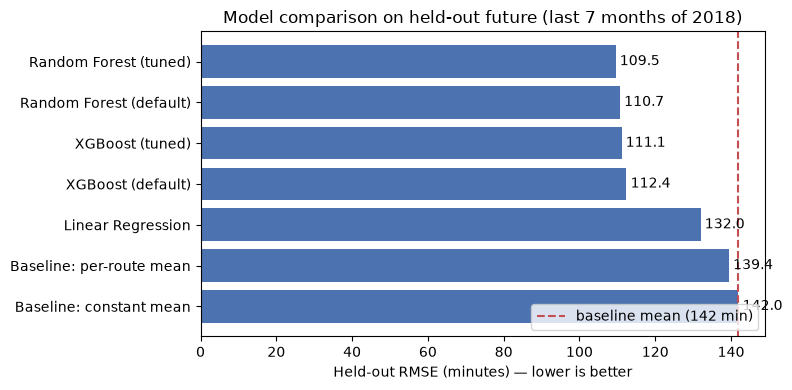

In [49]:
import matplotlib.pyplot as plt

_r = model_results.sort_values("held_out_rmse", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(_r["model"], _r["held_out_rmse"], color="#4C72B0")
ax.axvline(rmse_mean, color="#C44E52", linestyle="--", label=f"baseline mean ({rmse_mean:.0f} min)")
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_xlabel("Held-out RMSE (minutes) — lower is better")
ax.set_title("Model comparison on held-out future (last 7 months of 2018)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Before this step:** we know the ranking; now we lock in the winner as a single named object so the rest of the project has one clear handle.

**What this code does:** it selects the best model — the **tuned Random Forest** — as `best_model`, and prints its name and score. This is the model Phase 6 analyzes and Phase 6.3 saves to disk.

**What we want to get out of it:** one agreed `best_model` variable to carry into error analysis and deployment.

In [50]:
# Selected winner: the tuned Random Forest (lowest held-out RMSE, and simple to serve
# in the Phase 8 Streamlit app). Bound to one handle for Phase 6 onward.
best_model = rf_search.best_estimator_
best_name = "Random Forest (tuned)"
best_rmse = rmse_rf_tuned

print(f"Selected model: {best_name}")
print(f"Held-out RMSE : {best_rmse:.2f} min  (baseline {rmse_mean:.2f} -> {(rmse_mean - best_rmse) / rmse_mean * 100:.1f}% better)")
print("Params:", best_model.get_params())

Selected model: Random Forest (tuned)
Held-out RMSE : 109.53 min  (baseline 141.95 -> 22.8% better)
Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 16, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 391, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


**Takeaway (Phase 4.5):** The **tuned Random Forest** is our selected model — held-out RMSE **≈109.5 min**, about **23% better than the baseline** (142 min).

- **Clear tiers:** trees (109-112 min) >> linear (132 min) >> constant baselines (139-142 min). Learning genuinely helps; the algorithm choice among trees barely matters.
- **Winner rationale:** the tuned Random Forest scored best and is simple and fast to serve in the Phase 8 delay-alert app; tuned XGBoost (111 min) is a close, credible backup.
- **The headline caveat carries forward:** all tree models plateau in a tight band because of the upward 2018 **drift** — the model is now feature-limited, not algorithm-limited.
- **Next (Phase 6.1):** error analysis on `best_model` — where do the biggest misses concentrate (routes, season, hour, delay magnitude)? That points directly at which Phase 6.2 features (congestion, turnaround slack, Ramadan) are worth building.

## Phase 5.1: Draft stakeholder slide deck

Developed independently, see html file in repo. 

## Phase 6.1: Residual/error analysis

Now that the tuned Random Forest (`best_model`) is selected, we look at **where it goes wrong** — not just the single RMSE number. A *residual* is the gap between reality and the prediction:

> **residual = actual delay - predicted delay**

A positive residual means the flight was **more** delayed than predicted (we were too optimistic); a negative one means **less** delayed (too pessimistic). By slicing residuals across **delay magnitude, route, season, and aircraft**, we find the pockets where the model struggles - which tells Phase 6.2 exactly which new features are worth building.

All analysis is on the **held-out validation set** (`valid_split` / `X_valid_rf` / `y_valid`) - the last ~7 months of 2018 the model never saw during training.

**Before this step:** We have the selected model (`best_model`) and the held-out validation set, but only a single RMSE number describing its accuracy.

**What this code does:** Predicts the delay for every validation flight, then computes each flight's **residual** (`actual − predicted`) and prints a quick summary — the average residual (is the model biased high or low?), the median, and the spread.

**What we want to get out of it:** A first read on the model's error: a mean residual near 0 means no systematic bias overall; the standard deviation should be close to the RMSE (~110 min).

In [51]:
import matplotlib.pyplot as plt

# Predict on the held-out validation set, then measure the residual for each flight.
err = valid_split.copy()
err["pred"] = best_model.predict(X_valid_rf)
err["resid"] = err["target"] - err["pred"]   # actual - predicted

print(f"Validation flights analysed: {len(err):,}")
print(f"Mean residual:   {err['resid'].mean():.1f} min  (> 0 => model under-predicts on average)")
print(f"Median residual: {err['resid'].median():.1f} min")
print(f"Std of residual: {err['resid'].std():.1f} min  (~ the RMSE)")

Validation flights analysed: 21,567
Mean residual:   4.4 min  (> 0 => model under-predicts on average)
Median residual: -7.1 min
Std of residual: 109.4 min  (~ the RMSE)


**Before this step:** The summary numbers hide the *shape* of the errors.

**What this code does:** Draws a histogram of the residuals (clipped to ±300 min just so the chart is readable — the tails run much wider). The red line marks a perfect prediction (residual = 0).

**What we want to get out of it:** See whether errors are symmetric around zero or lopsided. A long right tail would mean the model frequently gets caught out by delays far larger than it predicted.

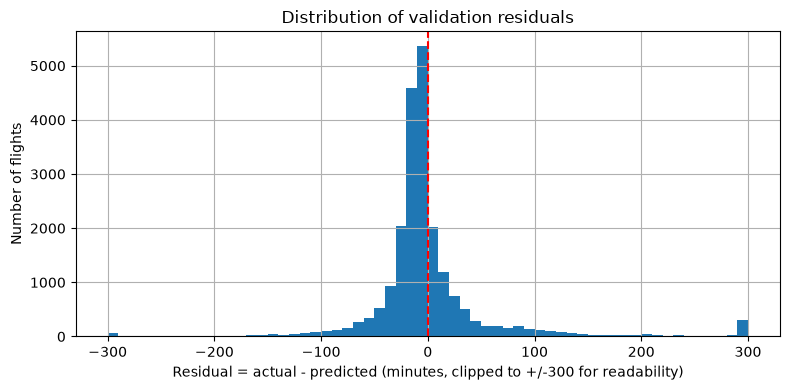

In [52]:
plt.figure(figsize=(8, 4))
err["resid"].clip(-300, 300).hist(bins=60)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual = actual - predicted (minutes, clipped to +/-300 for readability)")
plt.ylabel("Number of flights")
plt.title("Distribution of validation residuals")
plt.tight_layout()
plt.show()

**Before this step:** We know the error spread, but not *where* along the delay range the model tracks reality vs. breaks down.

**What this code does:** Plots each flight's predicted delay (x) against its actual delay (y). The red diagonal is where perfect predictions would land.

**What we want to get out of it:** If points fan out below the diagonal at high actual values, that visually confirms the model **under-predicts large delays** — it never dares to predict the big numbers.

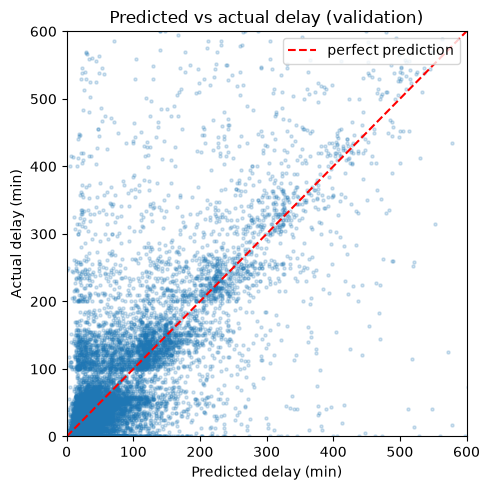

In [53]:
plt.figure(figsize=(5, 5))
plt.scatter(err["pred"], err["target"], s=5, alpha=0.2)
lim = 600
plt.plot([0, lim], [0, lim], color="red", linestyle="--", label="perfect prediction")
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.xlabel("Predicted delay (min)")
plt.ylabel("Actual delay (min)")
plt.title("Predicted vs actual delay (validation)")
plt.legend()
plt.tight_layout()
plt.show()

**Before this step:** We suspect the error depends on how delayed the flight actually was. Let's quantify it.

**What this code does:** Buckets validation flights into four delay bands — on-time (0–15 min), minor (15–60), moderate (60–180), severe (180+) — and shows, per band, the average actual delay, the average prediction, and the average residual. Then a bar chart of the mean residual per band.

**What we want to get out of it:** The clearest diagnostic of the model's weakness — we expect it to slightly *over*-predict on-time flights and heavily *under*-predict the severe band (positive residuals), which is what drives the RMSE.

                       n  mean_actual  mean_predicted  mean_residual
delay_band                                                          
on-time (0-15)     10096          3.3            22.5          -19.1
minor (15-60)       6360         33.9            42.7           -8.7
moderate (60-180)   3084        116.2           100.0           16.2
severe (180+)       2027        381.8           236.8          145.0


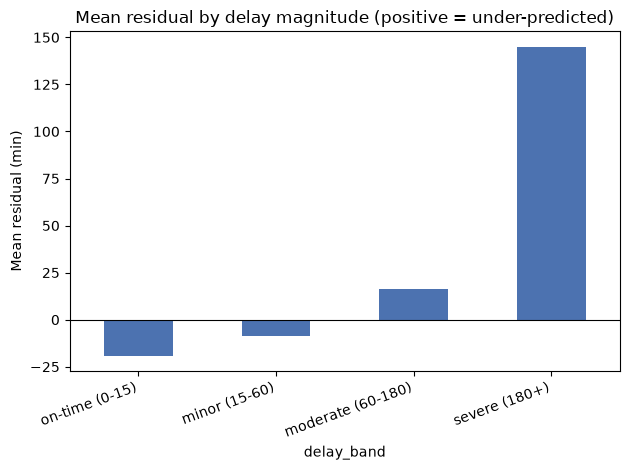

In [54]:
bands = [-1, 15, 60, 180, 1e9]
labels = ["on-time (0-15)", "minor (15-60)", "moderate (60-180)", "severe (180+)"]
err["delay_band"] = pd.cut(err["target"], bins=bands, labels=labels)

band_summary = err.groupby("delay_band", observed=True).agg(
    n=("resid", "size"),
    mean_actual=("target", "mean"),
    mean_predicted=("pred", "mean"),
    mean_residual=("resid", "mean"),
).round(1)
print(band_summary)

band_summary["mean_residual"].plot(kind="bar", color="#4C72B0")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Mean residual (min)")
plt.title("Mean residual by delay magnitude (positive = under-predicted)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Before this step:** Some routes may be systematically harder to predict than others.

**What this code does:** Groups validation flights by route (`DEPSTN->ARRSTN`) and reports, for routes with at least 30 validation flights, the mean residual and the mean absolute error (MAE) — sorted to show the 10 worst-predicted routes.

**What we want to get out of it:** Identify routes where the model is consistently off. If the worst offenders are infrequent long-haul routes, that points to a data-sparsity problem a route-frequency or congestion feature might help.

In [55]:
err["route"] = err["DEPSTN"] + "->" + err["ARRSTN"]
route_err = err.groupby("route").agg(
    n=("resid", "size"),
    mean_residual=("resid", "mean"),
    mae=("resid", lambda s: s.abs().mean()),
)
route_err[route_err["n"] >= 30].sort_values("mae", ascending=False).head(10).round(1)

,n,mean_residual,mae
route,,,
ABJ->OUA,36,11.1,141.8
ABJ->TUN,95,62.3,116.9
TUN->CDG,57,56.5,114.7
TOE->DJE,33,71.8,105.1
AMS->TUN,49,75.5,100.3
DSS->BKO,65,-15.4,97.1
VKO->MIR,46,0.3,92.6
DSS->CKY,38,-47.5,89.3
MIR->VKO,46,-39.9,87.3


**Before this step:** Phase 1.7 showed delays peak in summer. Does the model's *error* also vary by season?

**What this code does:** Groups validation flights by departure month and reports flight count, mean residual, and MAE per month.

**What we want to get out of it:** See whether error concentrates in peak months. **Caveat:** the chronological split means the validation set only covers the **second half of 2018** (≈ June–December), so this is a within-H2-2018 view, not a full-year seasonal comparison.

In [56]:
month_err = err.groupby("dep_month").agg(
    n=("resid", "size"),
    mean_residual=("resid", "mean"),
    mae=("resid", lambda s: s.abs().mean()),
).round(1)
month_err

,n,mean_residual,mae
dep_month,,,
6,3633,2.9,37.7
7,4263,3.6,32.6
8,4670,10.6,43.0
9,132,-9.6,25.7
10,3320,0.2,32.5
11,2578,0.3,31.3
12,2971,6.7,45.3


**Before this step:** Phase 1.7 found aircraft was only a weak driver of delay — but the model's *error* by aircraft is still worth a check.

**What this code does:** Groups validation flights by aircraft tail (`AC`) and reports mean residual and MAE for aircraft with at least 50 validation flights — 10 worst first.

**What we want to get out of it:** Confirm no single aircraft is dramatically mispredicted (which would hint at a plane-specific issue), or show that error is spread fairly evenly across the fleet.

In [57]:
ac_err = err.groupby("AC").agg(
    n=("resid", "size"),
    mean_residual=("resid", "mean"),
    mae=("resid", lambda s: s.abs().mean()),
)
ac_err[ac_err["n"] >= 50].sort_values("mae", ascending=False).head(10).round(1)

,n,mean_residual,mae
AC,,,
5K 345TFX,73,41.8,86.2
TU 32AIMM,343,32.5,71.6
GJ 734MGC,225,29.8,70.1
TU 332IFM,524,20.8,49.6
TU 32AIMG,884,11.0,49.0
GJ 734PGC,285,28.1,47.7
TU 32AIMD,824,13.1,46.6
TU 32AIMF,827,11.5,46.3
5M 343FOX,63,-1.1,46.2


### Takeaway (Phase 6.1) — where the model breaks, and what to build next

**Headline: the model is accurate on ordinary flights but systematically under-predicts big delays — it "regresses toward the middle."** Overall the median residual is **-7 min** (it slightly *over*-predicts the typical flight) while the mean is **+4 min**, because a minority of large under-predictions drag the average up. The residual histogram is sharply peaked at 0 with a long right tail; the std (109 min) is essentially the RMSE.

**1. By delay magnitude — the main story.** Error grows monotonically with the true delay:

| Band | n | mean actual | mean predicted | mean residual |
|---|---|---|---|---|
| on-time (0-15) | 10,096 | 3 | 22 | **-19** (over-predicts) |
| minor (15-60) | 6,360 | 34 | 43 | -9 |
| moderate (60-180) | 3,084 | 116 | 100 | +16 |
| severe (180+) | 2,027 | 382 | 237 | **+145** (under-predicts) |

The ~2,000 severe flights, each under-predicted by ~145 min on average, dominate the squared error — **the RMSE is essentially a severe-tail problem.** The model hedges toward safe mid-range predictions (that minimises RMSE given its current inputs); it simply can't yet *see* the conditions that cause a multi-hour delay.

**2. By route.** The worst-predicted routes (MAE 84-142 min) are all **low-frequency long-haul** routes — Abidjan (ABJ), Ouagadougou (OUA), Dakar (DSS), Bamako (BKO), Conakry (CKY), Moscow (VKO), plus CDG / Amsterdam. They sit far from Tunisair's dense short-haul core (Tunis-Europe/Maghreb) and have few training examples → this is **data sparsity**, not a route-specific quirk.

**3. By season (H2-2018 validation window).** Error is highest in **August (MAE 43) and December (45)** — peak summer travel and year-end holidays — consistent with the Phase 1.7 seasonal pattern. (September shows only 132 flights, a sparse patch at the split boundary, so its low MAE isn't meaningful.)

**4. By aircraft — a concrete lead.** The most-mispredicted aircraft are the **wet-lease / ACMI planes** flown by other carriers for Tunisair: `5K 345TFX` (MAE 86, mean resid +42), `GJ 734MGC` (70, +30), `GJ 734PGC` (48, +28) — the `5K` / `GJ` prefixes are subcontracted operators. They're consistently **under-predicted** (they run later than the mainline fleet the model implicitly expects). This validates the **wet-lease flag** idea already noted in `ISSUES.md`.

**What this points to for Phase 6.2 (feature/model iteration):**
- **Attack the severe tail — that's where the RMSE lives.** Two complementary angles:
  - *Disruption-risk features*: airport **congestion** at the scheduled hour, **turnaround slack** (gap to the tail's previous leg), leg-of-day sequence, hub/system load — the Tier-1 ideas in `ISSUES.md`. These are the missing "why a flight blows out" signals.
  - *Model the skew*: try a **log-transform of the target** or a tail-aware loss, so the model is less punished for daring to predict large delays.
- **Wet-lease / aircraft-type flag** — cheap, parseable from `AC`, and directly supported by the aircraft residuals above.
- **Rare-route handling** — congestion / hub-load features (or grouping sparse routes) should help the long-haul misses more than adding route dummies.
- **Ramadan flag** — a Tunisia-specific effect not captured by month/holiday; plausibly reduces the summer error.

**Bottom line:** the model has squeezed about all the current schedule/route/cascade features allow (~110 min RMSE, 23% better than baseline). The remaining error is concentrated in **severe delays on sparse long-haul routes and wet-lease aircraft**, and closing it needs **disruption-risk features and tail-aware modelling — not a different algorithm.**

## Phase 6.2: Iterate features/model based on error analysis

Guided by Phase 6.1, we add four leakage-safe features (congestion, aircraft type / wet-lease, leg-of-day, Ramadan) and test a log-transform of the target, then re-score against the selected model (RMSE 109.5).

**Before this step:** Phase 6.1 showed the model under-predicts severe delays and mispredicts wet-lease aircraft and sparse long-haul routes. We now engineer four new **leakage-safe, schedule-derived** features aimed at those gaps.

**What this code does:** Adds, to both `train` and `test`:
- `dep_congestion` — how many flights share the same departure airport + date + hour (gate/runway contention proxy). Computed on the full schedule.
- `ac_type` + `is_wet_lease` — parsed from `AC` (the token after the space; its carrier prefix `TU` = mainline, anything else e.g. `5K`/`GJ` = subcontracted wet-lease).
- `leg_of_day` — the aircraft's flight sequence number that day (delay accumulates down the chain).
- `dep_is_ramadan` — whether the departure date falls in Ramadan (Gregorian windows hard-coded for 2016-2018, avoiding an extra calendar dependency).

**What we want to get out of it:** Concrete signals for *why a flight blows out*, to test whether they shrink the severe-delay error.

In [58]:
# Ramadan Gregorian windows (approx) for the years the data spans.
RAMADAN = [("2016-06-06", "2016-07-05"),
           ("2017-05-27", "2017-06-24"),
           ("2018-05-16", "2018-06-14")]

def add_phase62_features(df):
    df = df.copy()
    dep_date = df["STD"].dt.date
    # Airport congestion: flights sharing departure airport + date + hour.
    df["dep_congestion"] = df.groupby(["DEPSTN", dep_date, "dep_hour"])["ID"].transform("count")
    # Aircraft type + wet-lease flag, parsed from AC (e.g. "TU 320IMW", "5K 345TFX").
    parts = df["AC"].str.split(" ", n=1, expand=True)
    df["ac_type"] = parts[1].str[:3]
    df["is_wet_lease"] = (parts[0] != "TU").astype(int)
    # Leg-of-day sequence per aircraft.
    df["leg_of_day"] = df.groupby(["AC", dep_date]).cumcount() + 1
    # Ramadan flag.
    r = pd.Series(False, index=df.index)
    for s, e in RAMADAN:
        r |= df["STD"].between(pd.Timestamp(s), pd.Timestamp(e) + pd.Timedelta(days=1))
    df["dep_is_ramadan"] = r.astype(int)
    return df

train = add_phase62_features(train)
test = add_phase62_features(test)

print("wet-lease share (train):", f'{train["is_wet_lease"].mean()*100:.1f}%',
      "| aircraft types:", train["ac_type"].nunique())
print("Ramadan flights (train):", int(train["dep_is_ramadan"].sum()),
      "| max congestion:", int(train["dep_congestion"].max()),
      "| max leg_of_day:", int(train["leg_of_day"].max()))
train[["AC", "ac_type", "is_wet_lease", "dep_congestion", "leg_of_day", "dep_is_ramadan"]].head()

wet-lease share (train): 7.5% | aircraft types: 16
Ramadan flights (train): 9101 | max congestion: 15 | max leg_of_day: 13


,AC,ac_type,is_wet_lease,dep_congestion,leg_of_day,dep_is_ramadan
0,5K 343TQY,343,1,1,1,0
1,5K 343TQY,343,1,5,2,0
2,5K 343TQY,343,1,2,3,0
3,5K 343TQY,343,1,6,1,0
4,5K 343TQY,343,1,1,2,0


**Before this step:** The new columns live on the full `train`/`test`, but the model trains on the chronological `train_split` / `valid_split`. `dep_congestion` and `leg_of_day` must come from the *full* schedule (not a split subset), so we map them across by the unique flight `ID`.

**What this code does:** Merges the four new features onto `train_split` and `valid_split` by `ID`, frequency-encodes `ac_type` (learned from training only, like the route encodings), and assembles the expanded feature matrix `FEATURES_V2`.

**What we want to get out of it:** Train/validation matrices identical to before plus the five new columns, ready for a like-for-like re-fit.

In [59]:
_new_cols = ["dep_congestion", "is_wet_lease", "ac_type", "leg_of_day", "dep_is_ramadan"]
_lookup = train[["ID"] + _new_cols]

train_split = train_split.merge(_lookup, on="ID", how="left")
valid_split = valid_split.merge(_lookup, on="ID", how="left")

# Frequency-encode ac_type from training only (leakage-safe).
_ac_counts = train_split["ac_type"].value_counts()
train_split["ac_type_freq"] = train_split["ac_type"].map(_ac_counts).fillna(0).astype(int)
valid_split["ac_type_freq"] = valid_split["ac_type"].map(_ac_counts).fillna(0).astype(int)

FEATURES_V2 = FEATURES_RF + ["dep_congestion", "leg_of_day", "dep_is_ramadan",
                             "is_wet_lease", "ac_type_freq"]
X_train_v2, X_valid_v2 = train_split[FEATURES_V2], valid_split[FEATURES_V2]

print("Features (V2):", len(FEATURES_V2), "=", len(FEATURES_RF), "base +", len(FEATURES_V2) - len(FEATURES_RF), "new")
print("Missing values -> train:", int(X_train_v2.isna().sum().sum()), "| valid:", int(X_valid_v2.isna().sum().sum()))

Features (V2): 17 = 12 base + 5 new
Missing values -> train: 0 | valid: 0


**Before this step:** We have the expanded feature set; now test whether it actually improves the *selected* model.

**What this code does:** Re-fits a Random Forest with the **same tuned hyperparameters** (`rf_search.best_params_`) on the new feature set, scores it on the held-out validation set, and compares to the selected model's RMSE (`best_rmse`).

**What we want to get out of it:** A like-for-like answer — same algorithm, same tuning, only the features changed — so any RMSE difference is attributable to the new features.

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_v2 = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
rf_v2.fit(X_train_v2, y_train)
pred_v2 = rf_v2.predict(X_valid_v2)
rmse_v2 = root_mean_squared_error(y_valid, pred_v2)

print(f"[RF + new features] validation RMSE: {rmse_v2:.2f} min")
print(f"[RF selected (base)] validation RMSE: {best_rmse:.2f} min")
print(f"Change from new features: {best_rmse - rmse_v2:+.2f} min")

[RF + new features] validation RMSE: 108.64 min
[RF selected (base)] validation RMSE: 109.53 min
Change from new features: +0.90 min


**Before this step:** The target is heavily right-skewed. A common remedy is to train on `log(1 + delay)` so the model isn't dominated by huge values, then invert the prediction.

**What this code does:** Fits the same model on the log-transformed target, inverts the predictions with `expm1`, and scores on the original minute scale so it's comparable.

**What we want to get out of it:** A direct test of whether modelling the skew helps. Note the tension: log-space rewards getting *small* delays right, but our metric (RMSE on minutes) is dominated by the *large* ones — so this may well score worse.

In [61]:
import numpy as np

rf_log = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
rf_log.fit(X_train_v2, np.log1p(y_train))
pred_log = np.expm1(rf_log.predict(X_valid_v2))
rmse_log = root_mean_squared_error(y_valid, pred_log)

print(f"[RF + new features, LOG target] validation RMSE: {rmse_log:.2f} min")
print(f"[RF + new features, raw target] validation RMSE: {rmse_v2:.2f} min")
print(f"[RF selected (base)]            validation RMSE: {best_rmse:.2f} min")

[RF + new features, LOG target] validation RMSE: 117.67 min
[RF + new features, raw target] validation RMSE: 108.64 min
[RF selected (base)]            validation RMSE: 109.53 min


**Before this step:** Whatever the RMSE change, we want to see how much the new features actually contributed.

**What this code does:** Prints the feature importances of the new-feature model, largest first.

**What we want to get out of it:** Confirmation of which new features carry signal (and which don't), guiding what to keep and what the real next lever is.

In [62]:
importances_v2 = pd.Series(rf_v2.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)
print("Feature importances (RF + new features):")
print(importances_v2.round(3).to_string())

Feature importances (RF + new features):
prev_leg_delay           0.380
hours_since_prior_leg    0.220
gc_distance_km           0.072
route_freq               0.055
leg_of_day               0.048
country_pair_freq        0.042
dep_hour                 0.039
dep_month                0.034
dep_congestion           0.025
tz_diff_hours            0.024
dep_dow                  0.022
ac_type_freq             0.021
is_domestic              0.011
dep_is_holiday           0.003
is_wet_lease             0.002
dep_is_ramadan           0.002
has_prior_leg            0.000


### Takeaway (Phase 6.2) — modest gains, and a clear diagnosis

**New best model: Random Forest + new features, held-out RMSE 108.64 min** — down from 109.53 (−0.9 min, ~0.8% better than the previously selected model, ~24% better than the 141.95 baseline). Small but real, and it costs nothing to keep.

**What worked (kept):**
- **`leg_of_day`** — the standout new feature (importance **0.048**, 5th overall). A plane's later legs of the day inherit accumulated delay — a genuine, cheap signal that complements the cascade features.
- **`dep_congestion`** (0.025) and **`ac_type_freq`** (0.021) — modest but positive contributions.

**What didn't (near-zero importance):**
- **`is_wet_lease`** (0.002) and **`dep_is_ramadan`** (0.002). Despite Phase 6.1 flagging wet-lease planes as mispredicted, a binary flag can't help: those misses are driven by the **severe-delay tail**, not a constant offset. Ramadan's effect is already absorbed by `dep_month`. We leave them in (harmless) but they are not doing work.

**Log-transform target — rejected.** Training on `log(1+delay)` scored **117.67 min**, ~9 min *worse*. It improves accuracy on small delays but our RMSE metric is dominated by the large ones, so optimizing log-space optimizes the wrong thing. Confirms the target should stay on its native scale.

**The real diagnosis.** Two rounds of cheap, schedule-derived features (Phase 2 + Phase 6.2) have taken us to a **~108-110 min plateau**. The dominant features remain `prev_leg_delay` and `hours_since_prior_leg` (0.38 + 0.22 = 60% of importance) — i.e. the model predicts delay mostly from *delay already in the system*. The residual error is concentrated in **severe delays whose causes are not in this dataset** (weather, ATC, mechanical). 

**→ This is a feature/data ceiling, not an algorithm one.** The next real lever is **external disruption data — weather first** (see the weather feasibility spike below). That, not more tuning, is what would move the severe-tail error.

**Recommendation:** adopt this model (`rf_v2`, RMSE 108.64) as the selected model for Phase 6.3, and carry the weather question into Phase 7 "future work" (or a stretch goal if the spike below looks promising).

### Weather: a feasibility check (evidence for future work)

Phase 6.1 concluded the residual error is dominated by **severe delays with causes not in this dataset**. Weather is the obvious candidate, so we ran a quick out-of-notebook feasibility check before committing to a full build. Using free **ERA5 reanalysis** (Open-Meteo historical API), we pulled 2016-2018 hourly **departure** weather (wind gusts, precipitation) for the three busiest airports (TUN, DJE, ORY — 59,529 flights) and joined it by airport + scheduled departure hour.

**The signal is real and, crucially, concentrated in the severe tail:**

| Wind-gust quintile (departure) | Mean delay | Median |
|---|---|---|
| calmest | 28.8 min | 7 |
| ... | 37.0 / 40.3 / 52.2 | 10 / 13 / 17 |
| strongest | 54.8 min | 19 |

| Condition | Mean delay | Severe rate (>=180 min) |
|---|---|---|
| Calm | 39.7 min | 5.1% |
| Adverse (gusts >=40 km/h or precip) | 54.4 min | **7.4%** |
| Precipitation | 59.1 min | 8.2% |

A clean monotonic dose-response for wind, and adverse weather lifts the **severe-delay rate by ~45%** (5.1% -> 7.4%) — exactly the flights that drive our RMSE.

**Why it's future work, not built here:**
- **Realistic payoff is modest** — a few RMSE *minutes*. Delay propagation (captured by `prev_leg_delay`) still dominates; weather adds tail signal, not a transformation.
- **Coverage & data quality** — a full build needs all ~135 airports, and ideally **METAR observations** (visibility/ceiling — the most aviation-relevant variables, absent from ERA5), which requires an IATA->ICAO mapping.
- **Leakage framing** — departure-airport weather at the scheduled hour is defensible as pre-departure information; a production model would use the *forecast* available at prediction time, not the realised observation.

**Conclusion:** weather is the single most promising lever beyond the current feature set, backed by the evidence above. It is carried into the Phase 7 slide deck as the headline **future-work** recommendation rather than built under the Day-3 deadline. *(This check used a live API; the code is kept out of the notebook so it stays reproducible offline.)*

## Phase 6.3: Final evaluation on held-out test set

Generate the Zindi submission and save the final models. A key finding about the test-set structure forces a two-track approach (documented just below).

A critical discovery shapes this phase. Inspecting the train/test split by month reveals that **Zindi holds out entire calendar months** (e.g. May 2016 is 94% test, September 2018 is 97% test; every other month is ~0% test). Because a test month's flights are almost all hidden, a test flight's *previous leg* on the same aircraft is — 98.9% of the time — **also a hidden test flight**.

**Consequence:** `prev_leg_delay` (our single most important feature, ~38% of the Random Forest's importance) **cannot be observed for the Zindi test set** — the prior leg's actual delay is hidden. `hours_since_prior_leg` and `has_prior_leg` are fine (they need only schedule *times*, which the test set provides).

**This is not leakage** — in a real airline operations room the previous leg has already landed before the current flight departs, so its delay *is* known at prediction time. It is unavailable here purely because of Zindi's month-block test format.

**Two-track decision (chosen with the team):**
1. **Operational model** — the full model *with* `prev_leg_delay` (held-out RMSE **108.64 min**). This is the honest measure of predictive capability for the airline-operations stakeholder, stated with its assumption (prior-leg delay known at prediction time). It is the model we save for the Phase 8 app.
2. **Submittable model** — a model *without* `prev_leg_delay`, using only features observable for the hidden test months. This is what we score on Zindi. It is weaker but honest.

**Before this step:** Phase 6.2 produced `rf_v2` (RF + new features), our best model. We formally adopt it as the selected operational model.

**What this code does:** Binds `rf_v2` to `best_model` / `best_rmse` for the rest of the notebook.

**What we want to get out of it:** A single clear handle for the selected operational model (RMSE 108.64).

In [63]:
best_model = rf_v2
best_name = "Random Forest + new features (operational)"
best_rmse = rmse_v2
print(f"Selected operational model: {best_name}")
print(f"Held-out validation RMSE: {best_rmse:.2f} min  (uses prev_leg_delay)")

Selected operational model: Random Forest + new features (operational)
Held-out validation RMSE: 108.64 min  (uses prev_leg_delay)


**Before this step:** We need to know the honest cost of dropping `prev_leg_delay` — i.e. how the *submittable* model performs.

**What this code does:** Builds `FEATURES_SUBMIT` (all Phase 6.2 features except `prev_leg_delay`), fits the same tuned Random Forest on it, and scores it on the same held-out validation set — a like-for-like comparison against the operational model.

**What we want to get out of it:** A defensible RMSE for the model we will actually submit to Zindi, and a clear read on how much of the model's power rested on that one feature.

In [64]:
FEATURES_SUBMIT = [f for f in FEATURES_V2 if f != "prev_leg_delay"]

rf_submit_val = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
rf_submit_val.fit(train_split[FEATURES_SUBMIT], y_train)
rmse_submit = root_mean_squared_error(y_valid, rf_submit_val.predict(valid_split[FEATURES_SUBMIT]))

print(f"[Operational | with prev_leg_delay] valid RMSE: {best_rmse:.2f} min")
print(f"[Submittable | no prev_leg_delay]   valid RMSE: {rmse_submit:.2f} min")
print(f"[Baseline    | constant mean]       valid RMSE: {rmse_mean:.2f} min")
print(f"Cost of dropping prev_leg_delay: +{rmse_submit - best_rmse:.2f} min")

[Operational | with prev_leg_delay] valid RMSE: 108.64 min
[Submittable | no prev_leg_delay]   valid RMSE: 130.92 min
[Baseline    | constant mean]       valid RMSE: 141.95 min
Cost of dropping prev_leg_delay: +22.29 min


**Before this step:** To predict the Zindi test set we must build every `FEATURES_SUBMIT` column on `test` — using only information available for the hidden months.

**What this code does:** (1) builds `route`/`country_pair` on both frames; (2) frequency-encodes `route`, `country_pair`, `ac_type` using **counts learned from the full training set** (counts ignore the target -> leakage-safe); (3) recomputes `hours_since_prior_leg` and `has_prior_leg` for `test` from the **combined** schedule (a test flight's prior-leg *time* is known even when its delay is not). `prev_leg_delay` is deliberately never built for test.

**What we want to get out of it:** A complete, leakage-safe feature matrix for `test` with zero missing values, ready for submission.

In [ ]:
# Route / country-pair labels on both frames.
for _df in (train, test):
    _df["route"] = _df["DEPSTN"] + "->" + _df["ARRSTN"]
    _df["country_pair"] = _df["dep_country"] + "->" + _df["arr_country"]

# Frequency encodings learned from the full training set (leakage-safe: counts only).
for col in ["route", "country_pair", "ac_type"]:
    counts = train[col].value_counts()
    train[col + "_freq"] = train[col].map(counts).fillna(0).astype(int)
    test[col + "_freq"] = test[col].map(counts).fillna(0).astype(int)

# Real schedule-based turnaround features for TEST, from the combined schedule.
# (Only STD *times* are used -- no delays -- so this is valid for the hidden months.)
_c = pd.concat([train[["ID", "AC", "STD"]], test[["ID", "AC", "STD"]]], ignore_index=True).sort_values(["AC", "STD"])
_gap_med = (train.sort_values(["AC", "STD"]).groupby("AC")["STD"].diff().dt.total_seconds() / 3600).median()
_c["hours_since_prior_leg"] = ((_c["STD"] - _c.groupby("AC")["STD"].shift(1)).dt.total_seconds() / 3600).fillna(_gap_med)
_c["has_prior_leg"] = _c.groupby("AC").cumcount().gt(0).astype(int)
_sched = _c.set_index("ID")
test["hours_since_prior_leg"] = test["ID"].map(_sched["hours_since_prior_leg"])
test["has_prior_leg"] = test["ID"].map(_sched["has_prior_leg"])

print("Missing values in test submission features:", int(test[FEATURES_SUBMIT].isna().sum().sum()))

**Before this step:** With test features ready, we train the final submittable model on **all** labelled data (train_split + valid_split) to maximise learning, then predict the Zindi test set.

**What this code does:** Fits the tuned Random Forest on the full training set using `FEATURES_SUBMIT`, predicts `test`, clips any negative predictions to 0 (a delay can't be negative), and writes `zindi_submission.csv` in the required `ID,target` format.

**What we want to get out of it:** A valid Zindi submission file, plus a sanity check that the predicted-delay distribution looks reasonable.

In [66]:
rf_submit = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
rf_submit.fit(train[FEATURES_SUBMIT], train["target"])
test_pred = np.clip(rf_submit.predict(test[FEATURES_SUBMIT]), 0, None)

submission = pd.DataFrame({"ID": test["ID"], "target": test_pred.round(2)})
submission.to_csv("zindi_submission.csv", index=False)
print("Saved zindi_submission.csv:", submission.shape)
print(submission["target"].describe().round(2).to_string())
submission.head()

Saved zindi_submission.csv: (9333, 2)
count    9333.00
mean       65.26
std        63.32
min         0.00
25%        28.93
50%        46.77
75%        78.02
max       672.52


,ID,target
0,test_id_0,3.75
1,test_id_1,59.25
2,test_id_2,38.91
3,test_id_3,41.77
4,test_id_4,33.56


**Before this step:** The operational model (with `prev_leg_delay`) is the one the Phase 8 delay-alert app will use. We refit it on all labelled data and persist it.

**What this code does:** Refits the operational model on the full training set with `FEATURES_V2`, then saves both models with `joblib` (bundled with their feature lists) under `models/`. The held-out 108.64 remains the reported performance estimate.

**What we want to get out of it:** Reusable model artifacts for Phase 8, and a clean end to the modelling pipeline.

In [67]:
import joblib

operational_model = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
operational_model.fit(train[FEATURES_V2], train["target"])

joblib.dump({"model": operational_model, "features": FEATURES_V2}, "models/delay_model.joblib")
joblib.dump({"model": rf_submit, "features": FEATURES_SUBMIT}, "models/delay_model_submittable.joblib")
print("Saved:")
print("  models/delay_model.joblib            (operational, with prev_leg_delay)")
print("  models/delay_model_submittable.joblib (Zindi, no prev_leg_delay)")

Saved:
  models/delay_model.joblib            (operational, with prev_leg_delay)
  models/delay_model_submittable.joblib (Zindi, no prev_leg_delay)


### Takeaway (Phase 6.3) — two-track final evaluation

The month-block structure of the Zindi test set (documented above) forced a two-track outcome:

| Model | Held-out valid RMSE | vs baseline | Role |
|---|---|---|---|
| **Operational** (with `prev_leg_delay`) | **108.64 min** | −23.5% | Headline capability for stakeholders; saved for the Phase 8 app |
| **Submittable** (no `prev_leg_delay`) | **130.92 min** | −7.8% | Zindi leaderboard submission (`zindi_submission.csv`) |
| Baseline (constant mean) | 141.95 min | — | Reference |

**The +22.29 min cost of dropping `prev_leg_delay` is the story, not a flaw.** It quantifies how much of flight delay is **propagation** — a late prior leg making the next one late. A real airline knows the prior leg's delay at departure time, so the operational model's 108.64 is its true capability; Zindi merely hides whole months, so the leaderboard model can't use it and lands at 130.92 (still meaningfully better than guessing the mean).

**Artifacts produced:**
- `zindi_submission.csv` — 9,333 predictions in `ID,target` format (mean ~65 min, all non-negative).
- `models/delay_model.joblib` — operational model + feature list (for the Phase 8 delay-alert app).
- `models/delay_model_submittable.joblib` — the Zindi model.

**For the slide deck (Phase 7.2):** headline the operational **108.64 min (−24% vs baseline)** *with its stated assumption*, and present the propagation insight as the key finding — "our strongest signal is delay already in the system, which a real airline sees but the competition hides." This is a sophisticated, defensible narrative rather than a caveat to hide.

**Phase 6 (error analysis + iteration + final evaluation) is complete.**

## Phase 7.1: Finalize PEP8, reproducible notebook

*Ongoing — a final pass on this notebook's style and reproducibility once modeling is complete.*

## Phase 7.2: Finalize slide deck (PDF)

*Tracked outside this notebook.*

## Phase 7.3: Add data product slide

*Tracked outside this notebook.*

## Phase 7.4: Rehearse and deliver the presentation

*Tracked outside this notebook.*

## Phase 8.1: Define delay-risk categories and alternative-flight logic

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.2: Build Streamlit app - input flight, show predicted delay + risk category

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.3: Add alternative-flight suggestion feature

*Tracked in a separate Streamlit app, not this notebook.*

## Phase 8.4: Polish app UI and prepare live demo for presentation

*Tracked in a separate Streamlit app, not this notebook.*